# Exploratory Data Analysis bằng PySpark

Nguyên tắc: chỉ phân tích tập train, aggregate bằng PySpark trước, chỉ `toPandas()` khi bảng đã nhỏ.

## 1. Overview bài toán

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession, functions as F
from pyspark.storagelevel import StorageLevel

cwd = Path.cwd().resolve()
if (cwd / "data_pyspark_parquet").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data_pyspark_parquet").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = Path(r"g:/ds")

PARQUET_DIR = PROJECT_ROOT / "data_pyspark_parquet"
MANIFEST_PATH = PARQUET_DIR / "clean_30d_label_sessions_manifest.json"

spark = (
    SparkSession.builder
    .appName("week3_task04_eda_with_pyspark")
    .master("local[*]")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

with MANIFEST_PATH.open(encoding="utf-8") as file:
    clean_manifest = json.load(file)

TRAIN_CLEAN_PATH = Path(clean_manifest["train_clean_path"])
CLEAN_JOIN_KEY_COLUMNS = clean_manifest["join_key_columns"]
CLEAN_COLUMN_CHUNKS = clean_manifest["column_chunks"]


def unique_preserve_order(values):
    seen = set()
    result = []
    for value in values:
        if value not in seen:
            seen.add(value)
            result.append(value)
    return result


def find_chunks_for_requested_columns(requested_columns, chunks=CLEAN_COLUMN_CHUNKS):
    requested_set = set(requested_columns)
    key_partition_set = set(clean_manifest["join_key_columns"] + clean_manifest["partition_columns"])
    non_key_requested = requested_set - key_partition_set
    selected_chunks = [chunk for chunk in chunks if non_key_requested.intersection(set(chunk["columns"]))]
    if not selected_chunks and chunks:
        selected_chunks = [chunks[0]]
    return selected_chunks


def read_clean_selected_columns(base_path, requested_columns, chunks=CLEAN_COLUMN_CHUNKS):
    requested_columns = unique_preserve_order(requested_columns)
    selected_chunks = find_chunks_for_requested_columns(requested_columns, chunks)
    result_df = None
    selected_so_far = set()

    for chunk in selected_chunks:
        chunk_path = Path(base_path) / chunk["chunk_id"]
        chunk_available_columns = set(chunk["columns"])
        requested_from_chunk = [
            column for column in requested_columns
            if column in chunk_available_columns and column not in selected_so_far
        ]
        read_columns = unique_preserve_order(CLEAN_JOIN_KEY_COLUMNS + requested_from_chunk)
        one_chunk_df = spark.read.parquet(str(chunk_path)).select(read_columns)

        if result_df is None:
            result_df = one_chunk_df
        else:
            result_df = result_df.join(one_chunk_df, on=CLEAN_JOIN_KEY_COLUMNS, how="left")

        selected_so_far.update(requested_from_chunk)

    final_columns = [column for column in requested_columns if column in result_df.columns]
    return result_df.select(final_columns)


plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
overview_columns = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "session_month_key",
    "has_full_30d_label_window",
    "future_30d_has_purchase",
    "future_30d_revenue",
]

eda_overview_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, overview_columns)
    .persist(StorageLevel.DISK_ONLY)
)

overview_row = eda_overview_df.agg(
    F.count(F.lit(1)).alias("train_session_count"),
    F.countDistinct("fullVisitorId").alias("train_user_count"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 1, 1).otherwise(0)).alias("sessions_with_full_30d_label"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 0, 1).otherwise(0)).alias("sessions_without_full_30d_label"),
    F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
    F.sum(F.when(F.col("future_30d_has_purchase") == 0, 1).otherwise(0)).alias("future_no_purchase_sessions"),
    F.sum(F.when(F.col("future_30d_has_purchase").isNull(), 1).otherwise(0)).alias("future_label_null_sessions"),
).collect()[0].asDict()

overview_row["future_purchase_rate_among_labeled_pct"] = round(
    overview_row["future_purchase_sessions"]
    / overview_row["sessions_with_full_30d_label"]
    * 100,
    4,
)
overview_row["full_30d_label_session_pct"] = round(
    overview_row["sessions_with_full_30d_label"]
    / overview_row["train_session_count"]
    * 100,
    4,
)

overview_pd = pd.DataFrame([overview_row])
display(overview_pd)

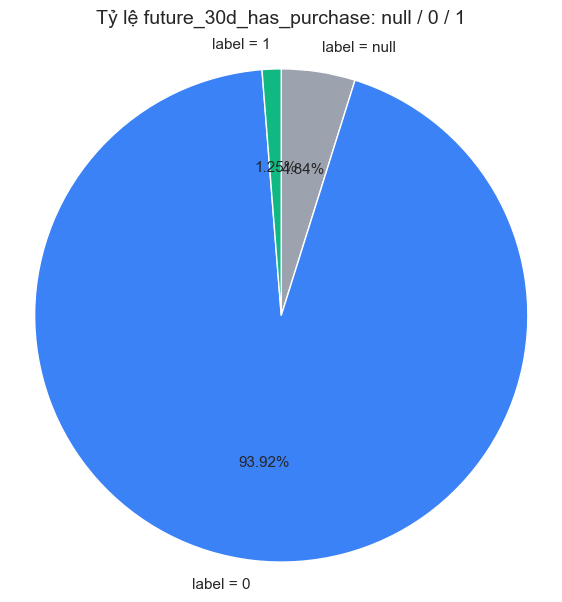

,future_purchase_label_status,session_count,session_pct
2,null,82535,4.8362
0,0,1602809,93.9175
1,1,21269,1.2463


In [ ]:
label_status_order = ["null", "0", "1"]
label_status_colors = {
    "null": "#9CA3AF",
    "0": "#3B82F6",
    "1": "#10B981",
}

label_status_df = (
    eda_overview_df
    .withColumn(
        "future_purchase_label_status",
        F.when(F.col("future_30d_has_purchase").isNull(), F.lit("null"))
        .otherwise(F.col("future_30d_has_purchase").cast("string")),
    )
    .groupBy("future_purchase_label_status")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .withColumn("session_pct", F.round(F.col("session_count") / F.lit(overview_row["train_session_count"]) * 100, 4))
)

label_status_pd = label_status_df.toPandas()
label_status_pd["future_purchase_label_status"] = pd.Categorical(
    label_status_pd["future_purchase_label_status"],
    categories=label_status_order,
    ordered=True,
)
label_status_pd = label_status_pd.sort_values("future_purchase_label_status")

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    label_status_pd["session_count"],
    labels=[f"label = {value}" for value in label_status_pd["future_purchase_label_status"].astype(str)],
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    colors=[label_status_colors[value] for value in label_status_pd["future_purchase_label_status"].astype(str)],
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
    textprops={"fontsize": 11},
)
ax.set_title("Tỷ lệ future_30d_has_purchase: null / 0 / 1", fontsize=14, pad=16)
ax.axis("equal")
plt.show()

display(label_status_pd)

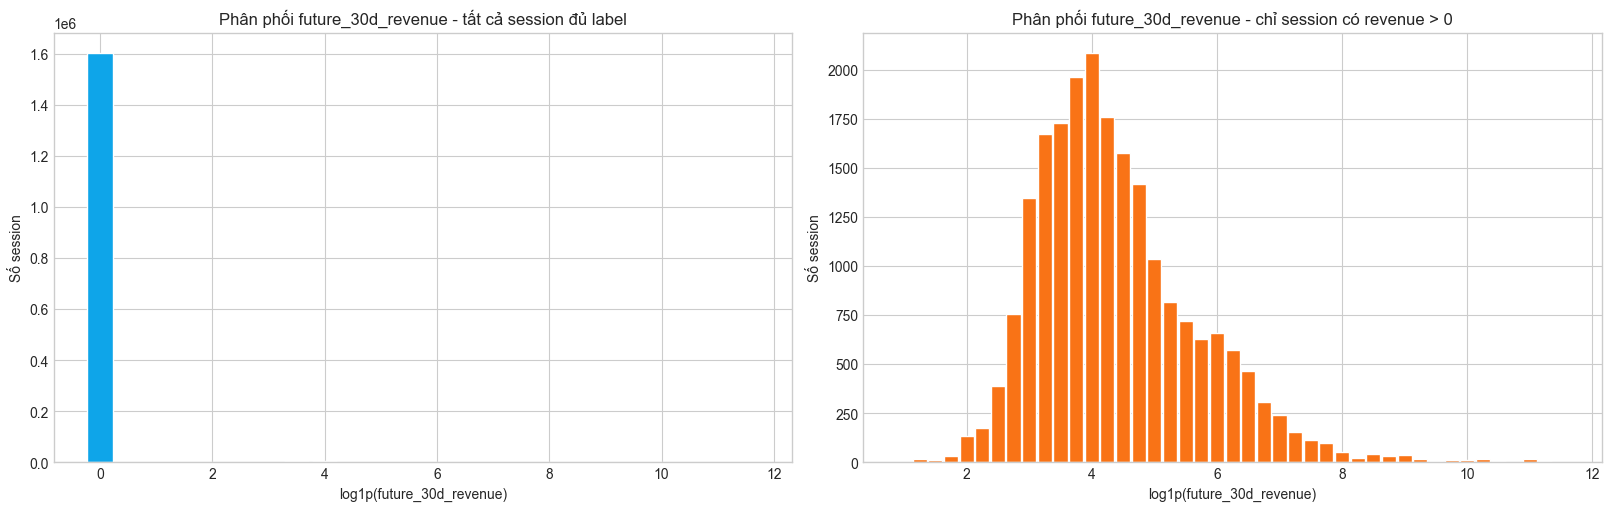

,labeled_session_count,zero_revenue_sessions,positive_revenue_sessions,avg_future_30d_revenue,p50_future_30d_revenue,p90_future_30d_revenue,p99_future_30d_revenue,max_future_30d_revenue
0,1624078,1602885,21193,5.5921,0.0,0.0,33.96,101456.79


In [ ]:
labeled_revenue_df = (
    eda_overview_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select(F.coalesce(F.col("future_30d_revenue"), F.lit(0.0)).alias("future_30d_revenue"))
    .persist(StorageLevel.DISK_ONLY)
)

revenue_summary = labeled_revenue_df.agg(
    F.count(F.lit(1)).alias("labeled_session_count"),
    F.sum(F.when(F.col("future_30d_revenue") == 0, 1).otherwise(0)).alias("zero_revenue_sessions"),
    F.sum(F.when(F.col("future_30d_revenue") > 0, 1).otherwise(0)).alias("positive_revenue_sessions"),
    F.round(F.avg("future_30d_revenue"), 4).alias("avg_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.5, 10000)"), 4).alias("p50_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.9, 10000)"), 4).alias("p90_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.99, 10000)"), 4).alias("p99_future_30d_revenue"),
    F.round(F.max("future_30d_revenue"), 4).alias("max_future_30d_revenue"),
).toPandas()

log_bin_width_all = 0.50
log_bin_width_positive = 0.25

revenue_hist_all_pd = (
    labeled_revenue_df
    .withColumn("revenue_log1p", F.log1p(F.col("future_30d_revenue")))
    .withColumn("revenue_log1p_bin", F.floor(F.col("revenue_log1p") / F.lit(log_bin_width_all)) * F.lit(log_bin_width_all))
    .groupBy("revenue_log1p_bin")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .orderBy("revenue_log1p_bin")
    .toPandas()
)

revenue_hist_positive_pd = (
    labeled_revenue_df
    .where(F.col("future_30d_revenue") > 0)
    .withColumn("revenue_log1p", F.log1p(F.col("future_30d_revenue")))
    .withColumn("revenue_log1p_bin", F.floor(F.col("revenue_log1p") / F.lit(log_bin_width_positive)) * F.lit(log_bin_width_positive))
    .groupBy("revenue_log1p_bin")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .orderBy("revenue_log1p_bin")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

axes[0].bar(
    revenue_hist_all_pd["revenue_log1p_bin"],
    revenue_hist_all_pd["session_count"],
    width=log_bin_width_all * 0.9,
    color="#0EA5E9",
    edgecolor="white",
)
axes[0].set_title("Phân phối future_30d_revenue - tất cả session đủ label")
axes[0].set_xlabel("log1p(future_30d_revenue)")
axes[0].set_ylabel("Số session")

axes[1].bar(
    revenue_hist_positive_pd["revenue_log1p_bin"],
    revenue_hist_positive_pd["session_count"],
    width=log_bin_width_positive * 0.9,
    color="#F97316",
    edgecolor="white",
)
axes[1].set_title("Phân phối future_30d_revenue - chỉ session có revenue > 0")
axes[1].set_xlabel("log1p(future_30d_revenue)")
axes[1].set_ylabel("Số session")

plt.show()

display(revenue_summary)

## 2. Phân tích target classification

Chỉ dùng các session có đủ cửa sổ label 30 ngày.

In [5]:
classification_labeled_df = (
    eda_overview_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select("fullVisitorId", "visit_id", "future_30d_has_purchase")
    .persist(StorageLevel.DISK_ONLY)
)

session_class_summary_pd = (
    classification_labeled_df
    .groupBy("future_30d_has_purchase")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .withColumn("target_level", F.lit("session"))
    .orderBy("future_30d_has_purchase")
    .toPandas()
)

user_class_df = (
    classification_labeled_df
    .groupBy("fullVisitorId")
    .agg(F.max("future_30d_has_purchase").alias("future_30d_has_purchase"))
)

user_class_summary_pd = (
    user_class_df
    .groupBy("future_30d_has_purchase")
    .agg(F.count(F.lit(1)).alias("user_count"))
    .withColumn("target_level", F.lit("user"))
    .orderBy("future_30d_has_purchase")
    .toPandas()
)

session_total = int(session_class_summary_pd["session_count"].sum())
user_total = int(user_class_summary_pd["user_count"].sum())

session_class_summary_pd["session_pct"] = session_class_summary_pd["session_count"] / session_total * 100
user_class_summary_pd["user_pct"] = user_class_summary_pd["user_count"] / user_total * 100

session_positive = int(session_class_summary_pd.loc[session_class_summary_pd["future_30d_has_purchase"] == 1, "session_count"].sum())
session_negative = int(session_class_summary_pd.loc[session_class_summary_pd["future_30d_has_purchase"] == 0, "session_count"].sum())
user_positive = int(user_class_summary_pd.loc[user_class_summary_pd["future_30d_has_purchase"] == 1, "user_count"].sum())
user_negative = int(user_class_summary_pd.loc[user_class_summary_pd["future_30d_has_purchase"] == 0, "user_count"].sum())

classification_summary_pd = pd.DataFrame([
    {
        "level": "session",
        "total_labeled": session_total,
        "future_purchase_count": session_positive,
        "future_no_purchase_count": session_negative,
        "future_purchase_rate_pct": round(session_positive / session_total * 100, 4),
        "negative_to_positive_ratio": round(session_negative / session_positive, 2),
    },
    {
        "level": "user",
        "total_labeled": user_total,
        "future_purchase_count": user_positive,
        "future_no_purchase_count": user_negative,
        "future_purchase_rate_pct": round(user_positive / user_total * 100, 4),
        "negative_to_positive_ratio": round(user_negative / user_positive, 2),
    },
])

display(classification_summary_pd)
display(session_class_summary_pd)
display(user_class_summary_pd)

,level,total_labeled,future_purchase_count,future_no_purchase_count,future_purchase_rate_pct,negative_to_positive_ratio
0,session,1624078,21269,1602809,1.3096,75.36
1,user,1262339,8154,1254185,0.6459,153.81


,future_30d_has_purchase,session_count,target_level,session_pct
0,0,1602809,session,98.690395
1,1,21269,session,1.309605


,future_30d_has_purchase,user_count,target_level,user_pct
0,0,1254185,user,99.354056
1,1,8154,user,0.645944


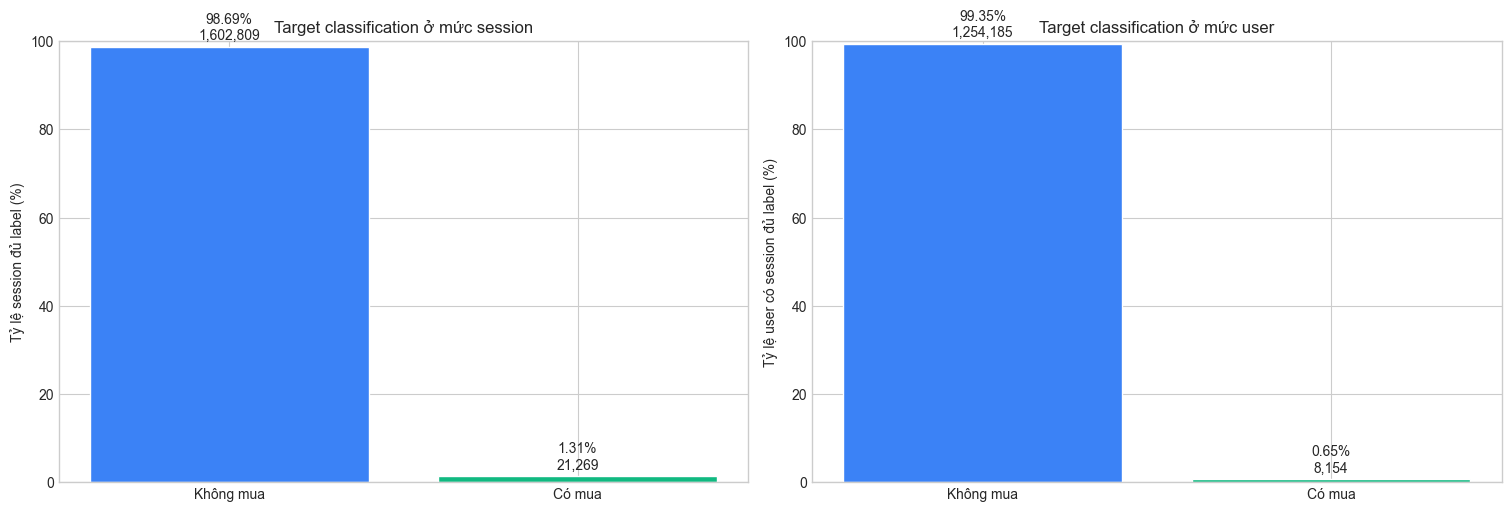

In [6]:
session_plot_pd = session_class_summary_pd.copy()
session_plot_pd["label"] = session_plot_pd["future_30d_has_purchase"].map({0: "Không mua", 1: "Có mua"})

user_plot_pd = user_class_summary_pd.copy()
user_plot_pd["label"] = user_plot_pd["future_30d_has_purchase"].map({0: "Không mua", 1: "Có mua"})

class_colors = ["#3B82F6", "#10B981"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].bar(session_plot_pd["label"], session_plot_pd["session_pct"], color=class_colors, edgecolor="white")
axes[0].set_title("Target classification ở mức session")
axes[0].set_ylabel("Tỷ lệ session đủ label (%)")
axes[0].set_ylim(0, 100)
for index, row in session_plot_pd.iterrows():
    axes[0].text(index, row["session_pct"] + 1, f"{row['session_pct']:.2f}%\n{row['session_count']:,}", ha="center", va="bottom", fontsize=10)

axes[1].bar(user_plot_pd["label"], user_plot_pd["user_pct"], color=class_colors, edgecolor="white")
axes[1].set_title("Target classification ở mức user")
axes[1].set_ylabel("Tỷ lệ user có session đủ label (%)")
axes[1].set_ylim(0, 100)
for index, row in user_plot_pd.iterrows():
    axes[1].text(index, row["user_pct"] + 1, f"{row['user_pct']:.2f}%\n{row['user_count']:,}", ha="center", va="bottom", fontsize=10)

plt.show()

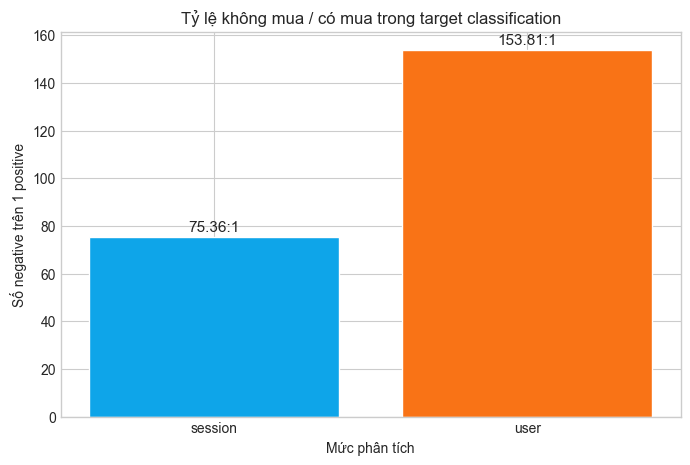

In [7]:
imbalance_plot_pd = classification_summary_pd.copy()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    imbalance_plot_pd["level"],
    imbalance_plot_pd["negative_to_positive_ratio"],
    color=["#0EA5E9", "#F97316"],
    edgecolor="white",
)

for bar, (_, row) in zip(bars, imbalance_plot_pd.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row['negative_to_positive_ratio']:.2f}:1",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_title("Tỷ lệ không mua / có mua trong target classification")
ax.set_ylabel("Số negative trên 1 positive")
ax.set_xlabel("Mức phân tích")
plt.show()

Ta có thể thấy bài toán bị mất cân bằng nghiêm trọng, tỉ lệ lệch giữa số session có doanh thu so với không có là cực kỳ lớn. Không chỉ vậy, số lượng user mua và không mua cũng bị lệch một cách nghiêm trọng.

Có thể áp dụng một vài kỹ thuật như under-sampling để giảm độ mất cân bằng dữ liệu.

## 3. Phân tích target revenue

Chỉ phân tích `future_30d_revenue` trên các session có đủ label 30 ngày. Với biểu đồ chi tiết, tách riêng nhóm revenue > 0 để không bị khối lượng zero revenue che hết phần đuôi.

In [8]:
revenue_target_df = (
    eda_overview_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select(F.coalesce(F.col("future_30d_revenue"), F.lit(0.0)).alias("future_30d_revenue"))
    .persist(StorageLevel.DISK_ONLY)
)

positive_revenue_df = revenue_target_df.where(F.col("future_30d_revenue") > 0).persist(StorageLevel.DISK_ONLY)

percentile_probs = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999, 1.0]
percentile_expr = "array(" + ", ".join(str(value) for value in percentile_probs) + ")"

def build_revenue_percentile_row(df, label):
    row = df.agg(
        F.count(F.lit(1)).alias("session_count"),
        F.round(F.avg("future_30d_revenue"), 4).alias("mean_revenue"),
        F.round(F.stddev("future_30d_revenue"), 4).alias("std_revenue"),
        F.expr(f"percentile_approx(future_30d_revenue, {percentile_expr}, 10000)").alias("percentiles"),
    ).collect()[0].asDict()
    result = {
        "scope": label,
        "session_count": row["session_count"],
        "mean_revenue": row["mean_revenue"],
        "std_revenue": row["std_revenue"],
    }
    for prob, value in zip(percentile_probs, row["percentiles"]):
        result[f"p{prob * 100:g}"] = round(float(value), 4)
    return result

revenue_percentile_pd = pd.DataFrame([
    build_revenue_percentile_row(revenue_target_df, "all_labeled_sessions"),
    build_revenue_percentile_row(positive_revenue_df, "positive_revenue_sessions"),
])

positive_revenue_cutoffs = revenue_percentile_pd.loc[
    revenue_percentile_pd["scope"] == "positive_revenue_sessions",
    ["p75", "p99", "p99.5", "p99.9"],
].iloc[0]

outlier_threshold = float(positive_revenue_cutoffs["p99"])
extreme_outlier_threshold = float(positive_revenue_cutoffs["p99.9"])

outlier_summary_pd = positive_revenue_df.agg(
    F.count(F.lit(1)).alias("positive_revenue_sessions"),
    F.sum(F.when(F.col("future_30d_revenue") > outlier_threshold, 1).otherwise(0)).alias("above_positive_p99_sessions"),
    F.sum(F.when(F.col("future_30d_revenue") > extreme_outlier_threshold, 1).otherwise(0)).alias("above_positive_p999_sessions"),
    F.round(F.avg(F.log1p("future_30d_revenue")), 4).alias("mean_log1p_positive_revenue"),
    F.round(F.stddev(F.log1p("future_30d_revenue")), 4).alias("std_log1p_positive_revenue"),
).toPandas()

outlier_summary_pd["positive_p99_threshold"] = outlier_threshold
outlier_summary_pd["positive_p999_threshold"] = extreme_outlier_threshold
outlier_summary_pd["above_positive_p99_pct"] = (
    outlier_summary_pd["above_positive_p99_sessions"]
    / outlier_summary_pd["positive_revenue_sessions"]
    * 100
).round(4)
outlier_summary_pd["above_positive_p999_pct"] = (
    outlier_summary_pd["above_positive_p999_sessions"]
    / outlier_summary_pd["positive_revenue_sessions"]
    * 100
).round(4)

display(revenue_percentile_pd)
display(outlier_summary_pd)

,scope,session_count,mean_revenue,std_revenue,p0,p25,p50,p75,p90,p95,p99,p99.5,p99.9,p100
0,all_labeled_sessions,1624078,5.5921,381.7335,0.00,0.00,0.00,0.00,0.00,0.00,33.96,102.96,662.55,101456.79
1,positive_revenue_sessions,21193,428.5368,3314.5474,2.04,35.98,71.96,179.01,559.15,948.04,5391.49,8689.97,65625.05,101456.79


,positive_revenue_sessions,above_positive_p99_sessions,above_positive_p999_sessions,mean_log1p_positive_revenue,std_log1p_positive_revenue,positive_p99_threshold,positive_p999_threshold,above_positive_p99_pct,above_positive_p999_pct
0,21193,204,10,4.5267,1.2907,5391.49,65625.05,0.9626,0.0472


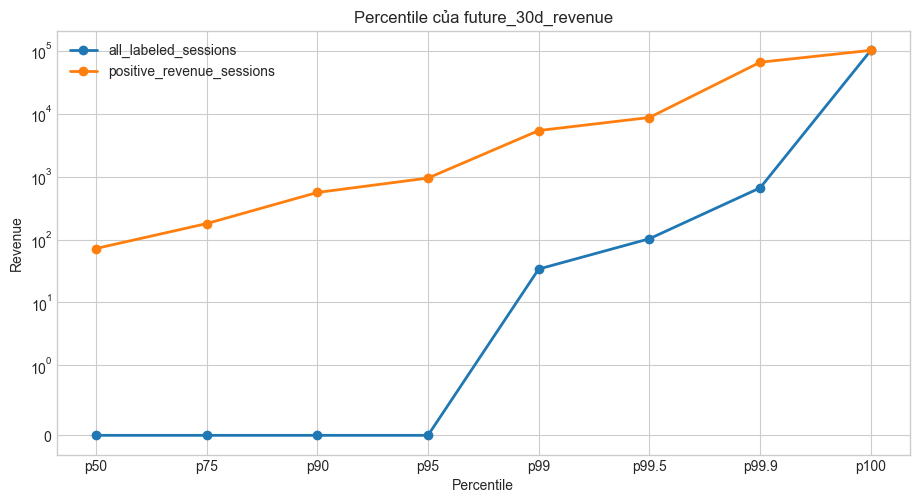

In [9]:
percentile_plot_pd = revenue_percentile_pd.melt(
    id_vars=["scope"],
    value_vars=["p50", "p75", "p90", "p95", "p99", "p99.5", "p99.9", "p100"],
    var_name="percentile",
    value_name="future_30d_revenue",
)
percentile_order = ["p50", "p75", "p90", "p95", "p99", "p99.5", "p99.9", "p100"]
percentile_plot_pd["percentile"] = pd.Categorical(percentile_plot_pd["percentile"], categories=percentile_order, ordered=True)
percentile_plot_pd = percentile_plot_pd.sort_values(["scope", "percentile"])

fig, ax = plt.subplots(figsize=(11, 5.5))
for scope, one_pd in percentile_plot_pd.groupby("scope", observed=True):
    ax.plot(
        one_pd["percentile"].astype(str),
        one_pd["future_30d_revenue"],
        marker="o",
        linewidth=2,
        label=scope,
    )

ax.set_title("Percentile của future_30d_revenue")
ax.set_xlabel("Percentile")
ax.set_ylabel("Revenue")
ax.set_yscale("symlog", linthresh=1)
ax.legend()
plt.show()

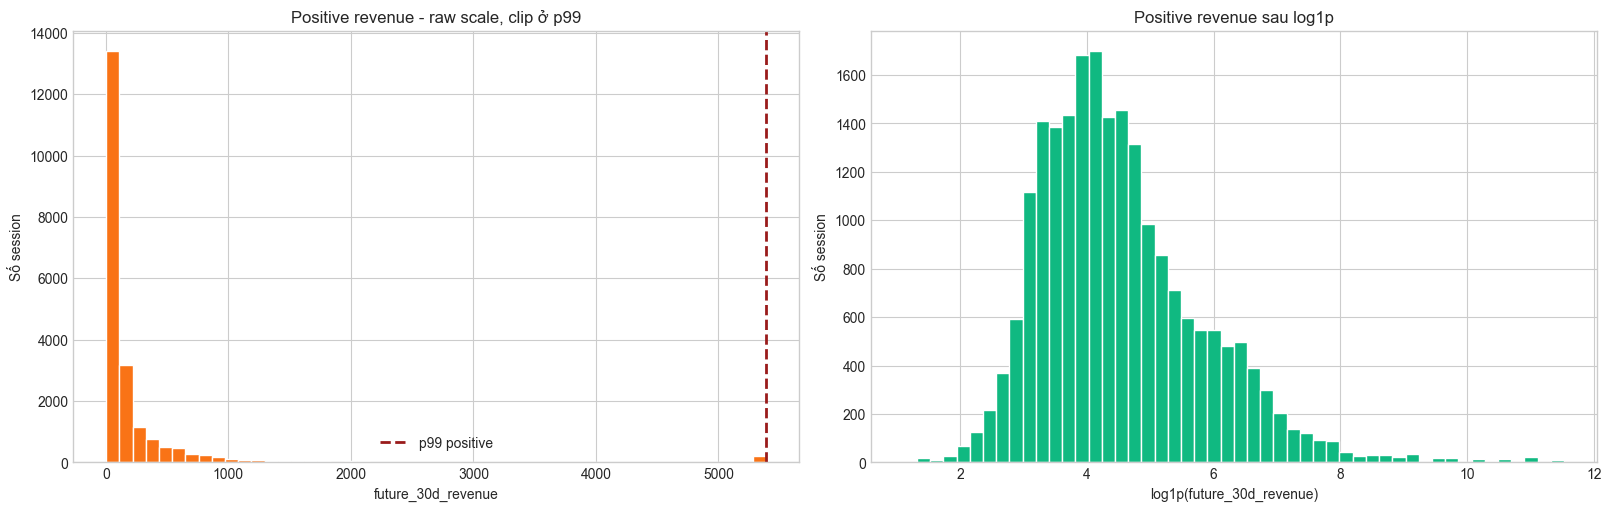

In [10]:
positive_revenue_pd = positive_revenue_df.select("future_30d_revenue").toPandas()
positive_revenue_pd["future_30d_revenue"] = positive_revenue_pd["future_30d_revenue"].astype(float)
positive_revenue_pd["future_30d_revenue_log1p"] = pd.Series(
    np.log1p(positive_revenue_pd["future_30d_revenue"]),
    index=positive_revenue_pd.index,
)

p99_positive_revenue = outlier_threshold
positive_revenue_clipped_pd = positive_revenue_pd.copy()
positive_revenue_clipped_pd["future_30d_revenue_clipped_p99"] = positive_revenue_clipped_pd["future_30d_revenue"].clip(upper=p99_positive_revenue)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

axes[0].hist(
    positive_revenue_clipped_pd["future_30d_revenue_clipped_p99"],
    bins=50,
    color="#F97316",
    edgecolor="white",
)
axes[0].axvline(p99_positive_revenue, color="#991B1B", linestyle="--", linewidth=2, label="p99 positive")
axes[0].set_title("Positive revenue - raw scale, clip ở p99")
axes[0].set_xlabel("future_30d_revenue")
axes[0].set_ylabel("Số session")
axes[0].legend()

axes[1].hist(
    positive_revenue_pd["future_30d_revenue_log1p"],
    bins=50,
    color="#10B981",
    edgecolor="white",
)
axes[1].set_title("Positive revenue sau log1p")
axes[1].set_xlabel("log1p(future_30d_revenue)")
axes[1].set_ylabel("Số session")

plt.show()

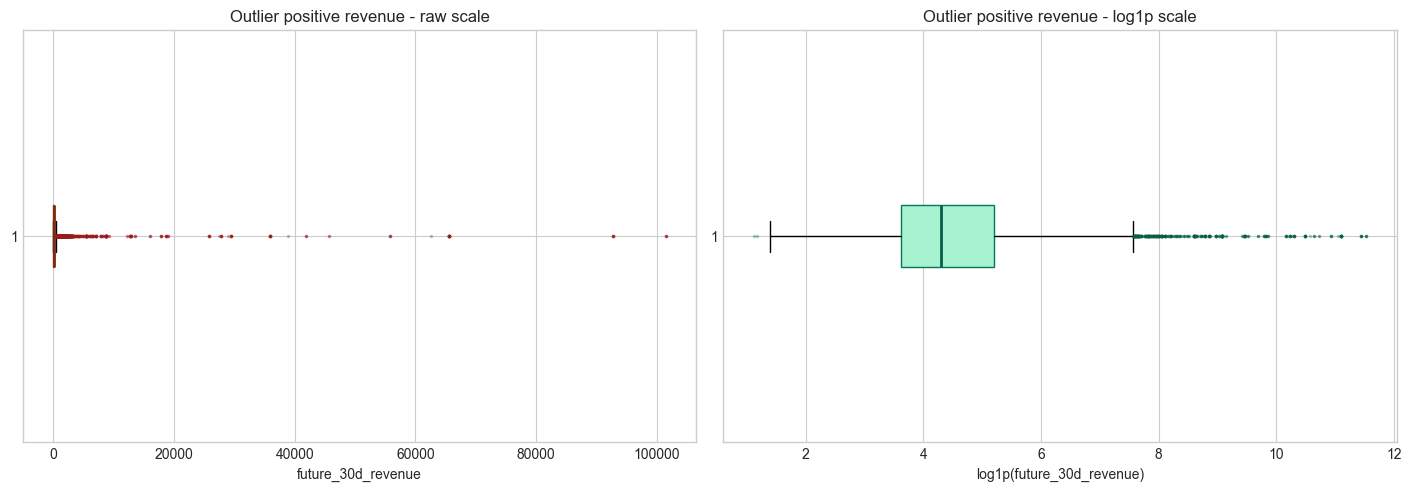

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

axes[0].boxplot(
    positive_revenue_pd["future_30d_revenue"],
    vert=False,
    showfliers=True,
    patch_artist=True,
    boxprops={"facecolor": "#FDBA74", "color": "#9A3412"},
    medianprops={"color": "#7C2D12", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "markerfacecolor": "#991B1B", "markeredgecolor": "#991B1B", "alpha": 0.25},
)
axes[0].set_title("Outlier positive revenue - raw scale")
axes[0].set_xlabel("future_30d_revenue")

axes[1].boxplot(
    positive_revenue_pd["future_30d_revenue_log1p"],
    vert=False,
    showfliers=True,
    patch_artist=True,
    boxprops={"facecolor": "#A7F3D0", "color": "#047857"},
    medianprops={"color": "#065F46", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "markerfacecolor": "#065F46", "markeredgecolor": "#065F46", "alpha": 0.25},
)
axes[1].set_title("Outlier positive revenue - log1p scale")
axes[1].set_xlabel("log1p(future_30d_revenue)")

plt.show()

Doanh thu future 30 ngày có dạng zero-inflated và long-tail: phần lớn session có revenue bằng 0, còn trong nhóm có revenue > 0 thì một số session rất lớn kéo max/mean lên mạnh. Vì vậy nên dùng `log1p(future_30d_revenue)` cho phân tích và modeling revenue, đặc biệt nếu dùng regression hoặc two-stage model.

## 4. Tạo `eda_train_df` theo từng nhóm

### 4.1. Nhóm `eda_base_keys_df`

Nhóm này giữ các key và cột thời gian nền để lọc train, lọc session đủ 30 ngày cho label, join các nhóm EDA khác và phân tích theo thời gian.

In [2]:
eda_base_keys_columns = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "session_year",
    "session_month",
    "session_month_key",
    "has_full_30d_label_window",
]

eda_base_keys_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_base_keys_columns)
    .persist(StorageLevel.DISK_ONLY)
)

# Base layer for later EDA groups. Subsequent groups will join into this dataframe by fullVisitorId + visit_id.
eda_train_df = eda_base_keys_df
eda_labeled_train_df = eda_train_df.where(F.col("has_full_30d_label_window") == 1)

eda_base_keys_df.printSchema()

root
 |-- fullVisitorId: string (nullable = true)
 |-- visit_id: long (nullable = true)
 |-- session_date: date (nullable = true)
 |-- session_year: integer (nullable = true)
 |-- session_month: integer (nullable = true)
 |-- session_month_key: string (nullable = true)
 |-- has_full_30d_label_window: integer (nullable = true)



In [3]:
eda_base_key_count_df = (
    eda_base_keys_df
    .groupBy("fullVisitorId", "visit_id")
    .agg(F.count(F.lit(1)).alias("rows_per_key"))
)

eda_base_overview_row = eda_base_keys_df.agg(
    F.count(F.lit(1)).alias("session_count"),
    F.countDistinct("fullVisitorId").alias("user_count"),
    F.sum(F.when(F.col("fullVisitorId").isNull() | F.col("visit_id").isNull(), 1).otherwise(0)).alias("null_join_key_sessions"),
    F.sum(F.when(F.col("session_date").isNull(), 1).otherwise(0)).alias("null_session_date_sessions"),
    F.min("session_date").alias("min_session_date"),
    F.max("session_date").alias("max_session_date"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 1, 1).otherwise(0)).alias("full_30d_label_sessions"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 0, 1).otherwise(0)).alias("incomplete_30d_label_sessions"),
).collect()[0].asDict()

distinct_session_key_count = eda_base_key_count_df.count()
duplicate_extra_rows = eda_base_key_count_df.where(F.col("rows_per_key") > 1).agg(
    F.coalesce(F.sum(F.col("rows_per_key") - 1), F.lit(0)).alias("duplicate_extra_rows")
).collect()[0]["duplicate_extra_rows"]

eda_base_overview_row["distinct_session_key_count"] = distinct_session_key_count
eda_base_overview_row["duplicate_extra_rows"] = int(duplicate_extra_rows or 0)
eda_base_overview_row["full_30d_label_session_pct"] = round(
    eda_base_overview_row["full_30d_label_sessions"] / eda_base_overview_row["session_count"] * 100,
    4,
)

eda_base_overview_pd = pd.DataFrame([eda_base_overview_row])
display(eda_base_overview_pd)

,session_count,user_count,null_join_key_sessions,null_session_date_sessions,min_session_date,max_session_date,full_30d_label_sessions,incomplete_30d_label_sessions,distinct_session_key_count,duplicate_extra_rows,full_30d_label_session_pct
0,1706613,1323730,0,0,2016-08-01,2018-04-30,1624078,82535,1706613,0,95.1638


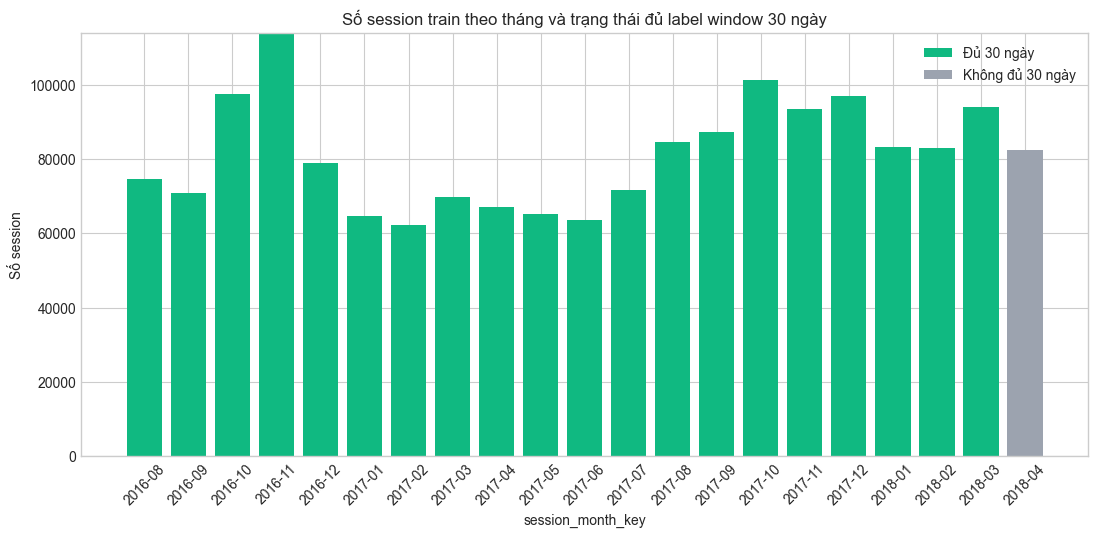

In [4]:
eda_base_monthly_label_window_pd = (
    eda_base_keys_df
    .groupBy("session_month_key", "has_full_30d_label_window")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .orderBy("session_month_key", "has_full_30d_label_window")
    .toPandas()
)

monthly_label_window_pivot_pd = (
    eda_base_monthly_label_window_pd
    .pivot(index="session_month_key", columns="has_full_30d_label_window", values="session_count")
    .fillna(0)
    .sort_index()
)
monthly_label_window_pivot_pd = monthly_label_window_pivot_pd.rename(columns={0: "Không đủ 30 ngày", 1: "Đủ 30 ngày"})

for column in ["Đủ 30 ngày", "Không đủ 30 ngày"]:
    if column not in monthly_label_window_pivot_pd.columns:
        monthly_label_window_pivot_pd[column] = 0

monthly_label_window_pivot_pd = monthly_label_window_pivot_pd[["Đủ 30 ngày", "Không đủ 30 ngày"]]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(
    monthly_label_window_pivot_pd.index,
    monthly_label_window_pivot_pd["Đủ 30 ngày"],
    color="#10B981",
    label="Đủ 30 ngày",
)
ax.bar(
    monthly_label_window_pivot_pd.index,
    monthly_label_window_pivot_pd["Không đủ 30 ngày"],
    bottom=monthly_label_window_pivot_pd["Đủ 30 ngày"],
    color="#9CA3AF",
    label="Không đủ 30 ngày",
)
ax.set_title("Số session train theo tháng và trạng thái đủ label window 30 ngày")
ax.set_xlabel("session_month_key")
ax.set_ylabel("Số session")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()


Ta sẽ bỏ đi tháng cuối của tập dữ liệu vì không đủ 30 cho nhãn.

### 4.2. Nhóm `eda_target_df`

`eda_target_df` gom toàn bộ target và target diagnostic vào một bảng session-level. Bảng này có thể dùng trực tiếp để trả lời nhanh các câu hỏi về purchase rate, class imbalance, revenue distribution, long-tail và thời gian tới lần mua đầu tiên.

In [5]:
eda_target_columns = [
    "fullVisitorId",
    "visit_id",
    "future_30d_has_purchase",
    "future_30d_revenue",
    "future_30d_purchase_count",
    "days_to_first_purchase",
    "has_full_30d_label_window",
]

eda_target_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_target_columns)
    .persist(StorageLevel.DISK_ONLY)
)

eda_target_labeled_df = eda_target_df.where(F.col("has_full_30d_label_window") == 1)

# Join target vào base EDA table. `has_full_30d_label_window` đã có trong base keys nên không join lặp cột này.
eda_train_df = (
    eda_base_keys_df
    .join(eda_target_df.drop("has_full_30d_label_window"), on=["fullVisitorId", "visit_id"], how="left")
    .persist(StorageLevel.DISK_ONLY)
)
eda_labeled_train_df = eda_train_df.where(F.col("has_full_30d_label_window") == 1)

eda_target_df.printSchema()

root
 |-- fullVisitorId: string (nullable = true)
 |-- visit_id: long (nullable = true)
 |-- future_30d_has_purchase: integer (nullable = true)
 |-- future_30d_revenue: double (nullable = true)
 |-- future_30d_purchase_count: integer (nullable = true)
 |-- days_to_first_purchase: integer (nullable = true)
 |-- has_full_30d_label_window: integer (nullable = true)



In [6]:
target_validation_row = eda_target_df.agg(
    F.count(F.lit(1)).alias("target_row_count"),
    F.countDistinct("fullVisitorId", "visit_id").alias("distinct_session_key_count"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 1, 1).otherwise(0)).alias("full_30d_label_sessions"),
    F.sum(F.when(F.col("has_full_30d_label_window") == 0, 1).otherwise(0)).alias("incomplete_30d_label_sessions"),
    F.sum(F.when(F.col("future_30d_has_purchase").isNull(), 1).otherwise(0)).alias("null_future_purchase_label_sessions"),
    F.sum(F.when((F.col("has_full_30d_label_window") == 1) & F.col("future_30d_has_purchase").isNull(), 1).otherwise(0)).alias("null_label_inside_full_window_sessions"),
).collect()[0].asDict()

target_metric_row = eda_target_labeled_df.agg(
    F.count(F.lit(1)).alias("labeled_session_count"),
    F.countDistinct("fullVisitorId").alias("labeled_user_count"),
    F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
    F.sum(F.when(F.col("future_30d_has_purchase") == 0, 1).otherwise(0)).alias("future_no_purchase_sessions"),
    F.sum(F.when(F.col("future_30d_revenue") > 0, 1).otherwise(0)).alias("positive_revenue_sessions"),
    F.sum(F.when(F.col("future_30d_revenue") == 0, 1).otherwise(0)).alias("zero_revenue_sessions"),
    F.round(F.avg("future_30d_revenue"), 4).alias("mean_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.5, 10000)"), 4).alias("p50_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.9, 10000)"), 4).alias("p90_future_30d_revenue"),
    F.round(F.expr("percentile_approx(future_30d_revenue, 0.99, 10000)"), 4).alias("p99_future_30d_revenue"),
    F.round(F.max("future_30d_revenue"), 4).alias("max_future_30d_revenue"),
    F.round(F.avg(F.when(F.col("future_30d_revenue") > 0, F.log1p("future_30d_revenue"))), 4).alias("mean_log1p_positive_revenue"),
    F.round(F.expr("percentile_approx(CASE WHEN future_30d_revenue > 0 THEN future_30d_revenue END, 0.99, 10000)"), 4).alias("positive_revenue_p99"),
    F.round(F.avg("future_30d_purchase_count"), 4).alias("mean_future_30d_purchase_count"),
    F.round(F.expr("percentile_approx(future_30d_purchase_count, 0.99, 10000)"), 4).alias("p99_future_30d_purchase_count"),
    F.round(F.avg(F.when(F.col("days_to_first_purchase").isNotNull(), F.col("days_to_first_purchase"))), 4).alias("mean_days_to_first_purchase_when_purchase"),
    F.round(F.expr("percentile_approx(days_to_first_purchase, 0.5, 10000)"), 4).alias("p50_days_to_first_purchase"),
).collect()[0].asDict()

target_summary_row = {**target_validation_row, **target_metric_row}
target_summary_row["future_purchase_rate_pct"] = round(
    target_summary_row["future_purchase_sessions"] / target_summary_row["labeled_session_count"] * 100,
    4,
)
target_summary_row["positive_revenue_rate_pct"] = round(
    target_summary_row["positive_revenue_sessions"] / target_summary_row["labeled_session_count"] * 100,
    4,
)
target_summary_row["negative_to_positive_ratio"] = round(
    target_summary_row["future_no_purchase_sessions"] / target_summary_row["future_purchase_sessions"],
    2,
)
target_summary_row["zero_revenue_rate_pct"] = round(
    target_summary_row["zero_revenue_sessions"] / target_summary_row["labeled_session_count"] * 100,
    4,
)
target_summary_row["revenue_long_tail_ratio_max_to_p99"] = round(
    target_summary_row["max_future_30d_revenue"] / target_summary_row["p99_future_30d_revenue"],
    2,
) if target_summary_row["p99_future_30d_revenue"] else None

eda_target_summary_pd = pd.DataFrame([target_summary_row])
display(eda_target_summary_pd)

,target_row_count,distinct_session_key_count,full_30d_label_sessions,incomplete_30d_label_sessions,null_future_purchase_label_sessions,null_label_inside_full_window_sessions,labeled_session_count,labeled_user_count,future_purchase_sessions,future_no_purchase_sessions,...,positive_revenue_p99,mean_future_30d_purchase_count,p99_future_30d_purchase_count,mean_days_to_first_purchase_when_purchase,p50_days_to_first_purchase,future_purchase_rate_pct,positive_revenue_rate_pct,negative_to_positive_ratio,zero_revenue_rate_pct,revenue_long_tail_ratio_max_to_p99
0,1706613,1706613,1624078,82535,82535,0,1624078,1262339,21269,1602809,...,5391.49,0.0155,1,7.4736,4,1.3096,1.3049,75.36,98.6951,2943.34


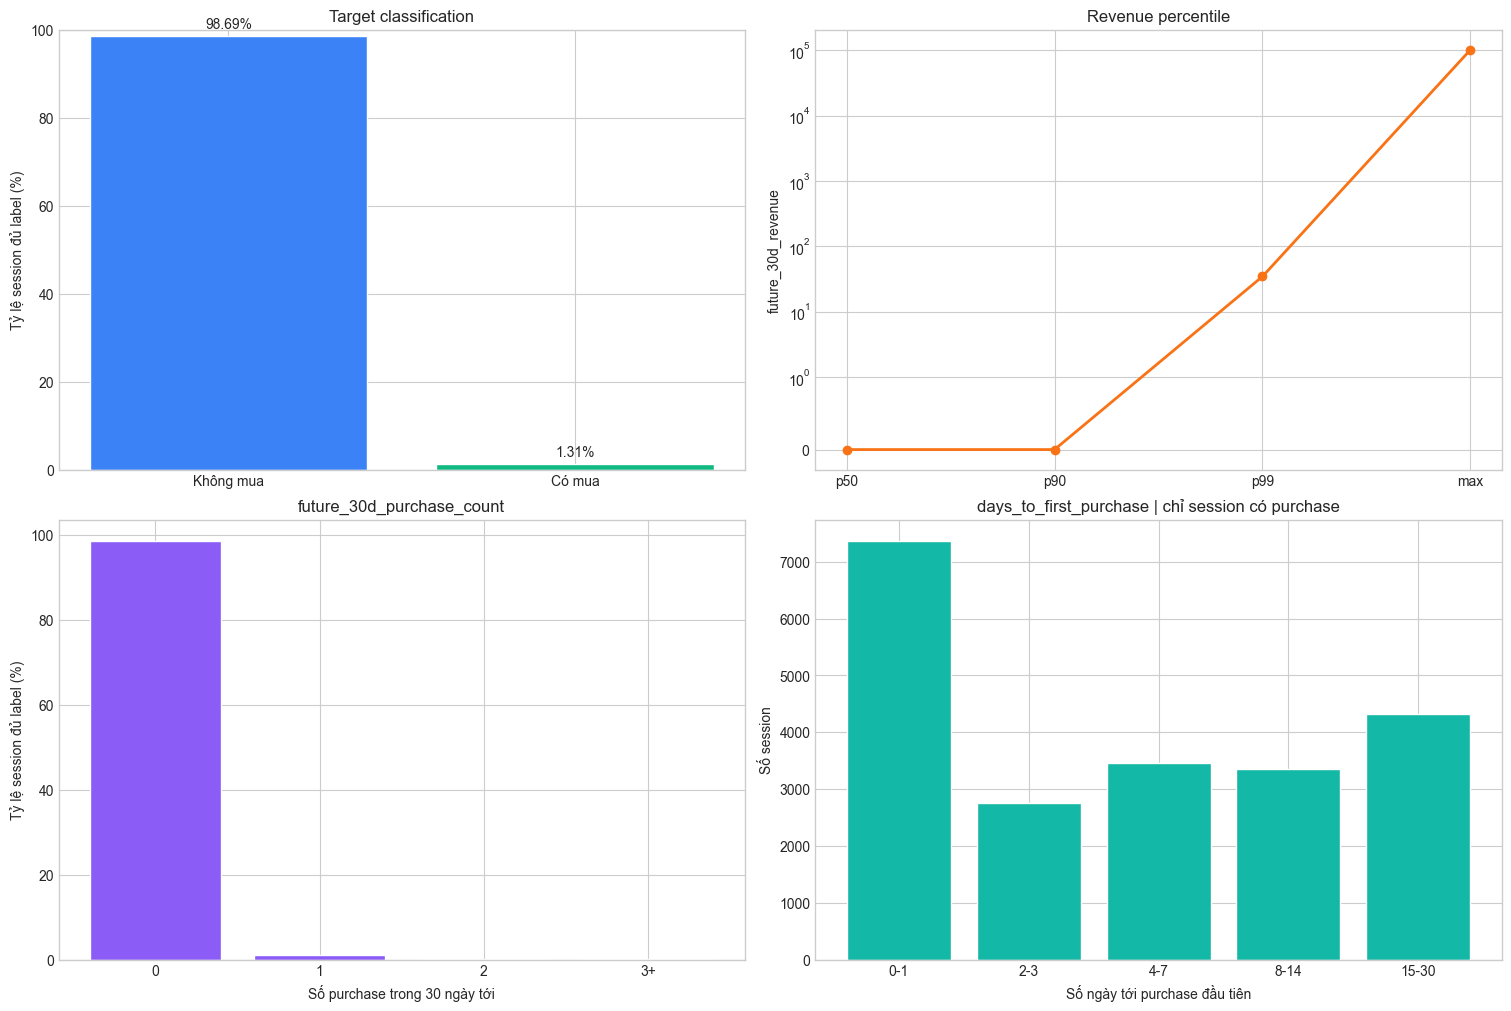

In [7]:
target_class_pd = pd.DataFrame([
    {"label": "Không mua", "session_count": target_summary_row["future_no_purchase_sessions"]},
    {"label": "Có mua", "session_count": target_summary_row["future_purchase_sessions"]},
])
target_class_pd["session_pct"] = target_class_pd["session_count"] / target_summary_row["labeled_session_count"] * 100

target_revenue_percentile_pd = pd.DataFrame([
    {"percentile": "p50", "future_30d_revenue": target_summary_row["p50_future_30d_revenue"]},
    {"percentile": "p90", "future_30d_revenue": target_summary_row["p90_future_30d_revenue"]},
    {"percentile": "p99", "future_30d_revenue": target_summary_row["p99_future_30d_revenue"]},
    {"percentile": "max", "future_30d_revenue": target_summary_row["max_future_30d_revenue"]},
])

purchase_count_pd = (
    eda_target_labeled_df
    .groupBy("future_30d_purchase_count")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .withColumn(
        "purchase_count_bucket",
        F.when(F.col("future_30d_purchase_count") >= 3, F.lit("3+"))
        .otherwise(F.col("future_30d_purchase_count").cast("string")),
    )
    .groupBy("purchase_count_bucket")
    .agg(F.sum("session_count").alias("session_count"))
    .toPandas()
)
purchase_count_order = ["0", "1", "2", "3+"]
purchase_count_pd["purchase_count_bucket"] = pd.Categorical(purchase_count_pd["purchase_count_bucket"], categories=purchase_count_order, ordered=True)
purchase_count_pd = purchase_count_pd.sort_values("purchase_count_bucket")
purchase_count_pd["session_pct"] = purchase_count_pd["session_count"] / target_summary_row["labeled_session_count"] * 100

days_to_purchase_pd = (
    eda_target_labeled_df
    .where(F.col("days_to_first_purchase").isNotNull())
    .withColumn(
        "days_bucket",
        F.when(F.col("days_to_first_purchase") <= 1, F.lit("0-1"))
        .when(F.col("days_to_first_purchase") <= 3, F.lit("2-3"))
        .when(F.col("days_to_first_purchase") <= 7, F.lit("4-7"))
        .when(F.col("days_to_first_purchase") <= 14, F.lit("8-14"))
        .otherwise(F.lit("15-30")),
    )
    .groupBy("days_bucket")
    .agg(F.count(F.lit(1)).alias("session_count"))
    .toPandas()
)
days_bucket_order = ["0-1", "2-3", "4-7", "8-14", "15-30"]
days_to_purchase_pd["days_bucket"] = pd.Categorical(days_to_purchase_pd["days_bucket"], categories=days_bucket_order, ordered=True)
days_to_purchase_pd = days_to_purchase_pd.sort_values("days_bucket")

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

axes[0, 0].bar(target_class_pd["label"], target_class_pd["session_pct"], color=["#3B82F6", "#10B981"], edgecolor="white")
axes[0, 0].set_title("Target classification")
axes[0, 0].set_ylabel("Tỷ lệ session đủ label (%)")
axes[0, 0].set_ylim(0, 100)
for index, row in target_class_pd.iterrows():
    axes[0, 0].text(index, row["session_pct"] + 1, f"{row['session_pct']:.2f}%", ha="center", va="bottom")

axes[0, 1].plot(target_revenue_percentile_pd["percentile"], target_revenue_percentile_pd["future_30d_revenue"], marker="o", color="#F97316", linewidth=2)
axes[0, 1].set_title("Revenue percentile")
axes[0, 1].set_ylabel("future_30d_revenue")
axes[0, 1].set_yscale("symlog", linthresh=1)

axes[1, 0].bar(purchase_count_pd["purchase_count_bucket"].astype(str), purchase_count_pd["session_pct"], color="#8B5CF6", edgecolor="white")
axes[1, 0].set_title("future_30d_purchase_count")
axes[1, 0].set_xlabel("Số purchase trong 30 ngày tới")
axes[1, 0].set_ylabel("Tỷ lệ session đủ label (%)")

axes[1, 1].bar(days_to_purchase_pd["days_bucket"].astype(str), days_to_purchase_pd["session_count"], color="#14B8A6", edgecolor="white")
axes[1, 1].set_title("days_to_first_purchase | chỉ session có purchase")
axes[1, 1].set_xlabel("Số ngày tới purchase đầu tiên")
axes[1, 1].set_ylabel("Số session")

plt.show()

Đối với những session có purchase thì thường người ta sẽ mua ngay sau đó một thời gian không quá lâu.

### 4.3. Nhóm `eda_time_df`

Nhóm này giữ các cột thời gian session-level để phân tích xu hướng theo tháng, ngày trong tuần, giờ trong ngày và kiểm tra giai đoạn thiếu label window.

In [18]:
eda_time_columns = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "session_year",
    "session_month",
    "session_month_key",
    "session_day_of_week",
    "session_hour",
]

eda_time_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_time_columns + ["has_full_30d_label_window"])
    .persist(StorageLevel.DISK_ONLY)
)

if "eda_base_keys_df" not in globals():
    eda_base_keys_columns = [
        "fullVisitorId",
        "visit_id",
        "session_date",
        "session_year",
        "session_month",
        "session_month_key",
        "has_full_30d_label_window",
    ]
    eda_base_keys_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_base_keys_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

if "eda_target_df" not in globals():
    eda_target_columns = [
        "fullVisitorId",
        "visit_id",
        "future_30d_has_purchase",
        "future_30d_revenue",
        "future_30d_purchase_count",
        "days_to_first_purchase",
        "has_full_30d_label_window",
    ]
    eda_target_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_target_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

# Rebuild from stable source tables so this cell can be rerun without duplicate time columns.
eda_train_df = (
    eda_base_keys_df
    .join(eda_target_df.drop("has_full_30d_label_window"), on=["fullVisitorId", "visit_id"], how="left")
    .join(
        eda_time_df.select("fullVisitorId", "visit_id", "session_day_of_week", "session_hour"),
        on=["fullVisitorId", "visit_id"],
        how="left",
    )
    .persist(StorageLevel.DISK_ONLY)
)
eda_labeled_train_df = eda_train_df.where(F.col("has_full_30d_label_window") == 1)
eda_time_labeled_df = eda_labeled_train_df.select(
    "fullVisitorId",
    "visit_id",
    "session_date",
    "session_year",
    "session_month",
    "session_month_key",
    "session_day_of_week",
    "session_hour",
    "future_30d_has_purchase",
    "future_30d_revenue",
)

eda_time_df.printSchema()

root
 |-- fullVisitorId: string (nullable = true)
 |-- visit_id: long (nullable = true)
 |-- session_date: date (nullable = true)
 |-- session_year: integer (nullable = true)
 |-- session_month: integer (nullable = true)
 |-- session_month_key: string (nullable = true)
 |-- session_day_of_week: integer (nullable = true)
 |-- session_hour: integer (nullable = true)
 |-- has_full_30d_label_window: integer (nullable = true)



In [19]:
eda_time_overview_pd = eda_time_df.agg(
    F.count(F.lit(1)).alias("time_row_count"),
    F.countDistinct("fullVisitorId", "visit_id").alias("distinct_session_key_count"),
    F.sum(F.when(F.col("session_date").isNull(), 1).otherwise(0)).alias("null_session_date_sessions"),
    F.sum(F.when(F.col("session_day_of_week").isNull(), 1).otherwise(0)).alias("null_day_of_week_sessions"),
    F.sum(F.when(F.col("session_hour").isNull(), 1).otherwise(0)).alias("null_session_hour_sessions"),
    F.min("session_date").alias("min_session_date"),
    F.max("session_date").alias("max_session_date"),
    F.min("session_hour").alias("min_session_hour"),
    F.max("session_hour").alias("max_session_hour"),
).toPandas()

display(eda_time_overview_pd)

,time_row_count,distinct_session_key_count,null_session_date_sessions,null_day_of_week_sessions,null_session_hour_sessions,min_session_date,max_session_date,min_session_hour,max_session_hour
0,1706613,1706613,0,0,0,2016-08-01,2018-04-30,0,23


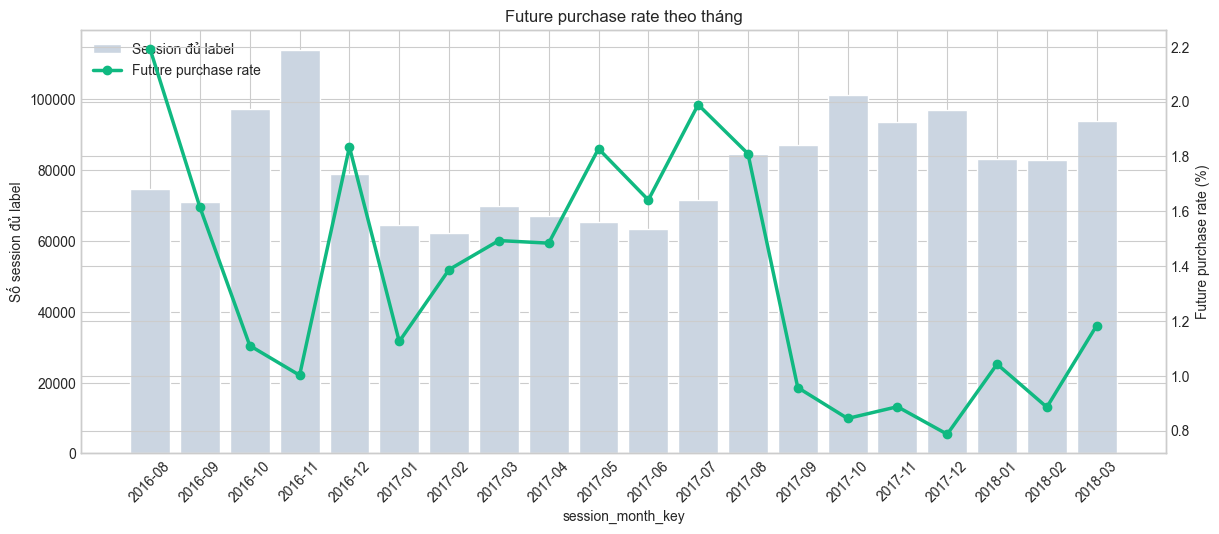

,session_month_key,labeled_session_count,future_purchase_sessions,avg_future_30d_revenue,future_purchase_rate_pct
0,2016-08,74676,1636,6.2660,2.1908
1,2016-09,70945,1145,3.2270,1.6139
2,2016-10,97426,1081,3.7879,1.1096
3,2016-11,113907,1141,2.5344,1.0017
4,2016-12,79049,1450,3.6868,1.8343
5,2017-01,64633,727,3.5558,1.1248
6,2017-02,62150,862,4.5541,1.3870
7,2017-03,69862,1043,31.6624,1.4929
8,2017-04,67070,995,17.7291,1.4835
9,2017-05,65271,1193,5.6896,1.8278


In [20]:
time_monthly_target_pd = (
    eda_time_labeled_df
    .groupBy("session_month_key")
    .agg(
        F.count(F.lit(1)).alias("labeled_session_count"),
        F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
        F.round(F.avg("future_30d_revenue"), 4).alias("avg_future_30d_revenue"),
    )
    .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
    .orderBy("session_month_key")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(14, 5.5))
ax1.bar(time_monthly_target_pd["session_month_key"], time_monthly_target_pd["labeled_session_count"], color="#CBD5E1", edgecolor="white", label="Session đủ label")
ax1.set_xlabel("session_month_key")
ax1.set_ylabel("Số session đủ label")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(time_monthly_target_pd["session_month_key"], time_monthly_target_pd["future_purchase_rate_pct"], color="#10B981", marker="o", linewidth=2.5, label="Future purchase rate")
ax2.set_ylabel("Future purchase rate (%)")

ax1.set_title("Future purchase rate theo tháng")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()

display(time_monthly_target_pd)

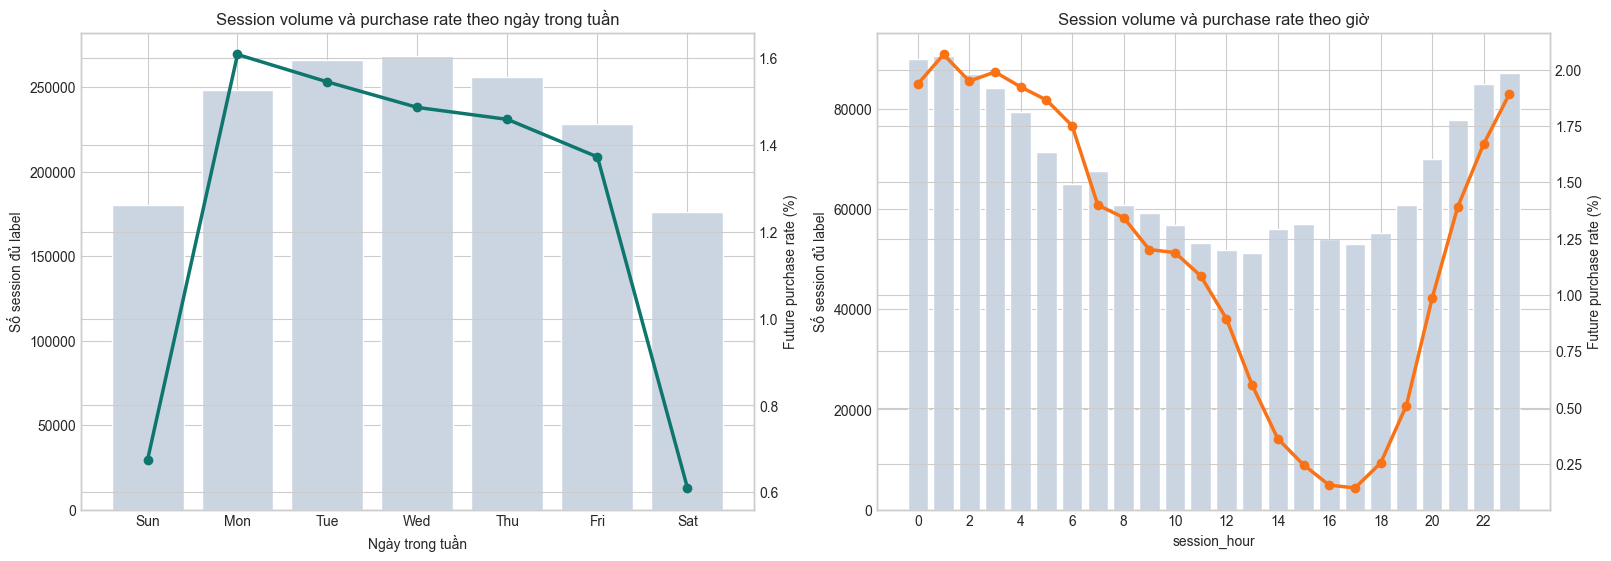

,session_day_of_week,labeled_session_count,future_purchase_sessions,future_purchase_rate_pct,day_name
0,1,180195,1215,0.6743,Sun
1,2,248644,4000,1.6087,Mon
2,3,266389,4117,1.5455,Tue
3,4,268785,3996,1.4867,Wed
4,5,255818,3733,1.4592,Thu
5,6,228377,3135,1.3727,Fri
6,7,175870,1073,0.6101,Sat


,session_hour,labeled_session_count,future_purchase_sessions,future_purchase_rate_pct
0,0,89984,1743,1.9370
1,1,90644,1874,2.0674
2,2,87016,1696,1.9491
3,3,84228,1676,1.9898
4,4,79289,1525,1.9233
5,5,71407,1332,1.8654
6,6,65048,1139,1.7510
7,7,67557,945,1.3988
8,8,60739,816,1.3435
9,9,59262,712,1.2014


In [21]:
day_name_map = {
    1: "Sun",
    2: "Mon",
    3: "Tue",
    4: "Wed",
    5: "Thu",
    6: "Fri",
    7: "Sat",
}

time_dow_target_pd = (
    eda_time_labeled_df
    .groupBy("session_day_of_week")
    .agg(
        F.count(F.lit(1)).alias("labeled_session_count"),
        F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
    )
    .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
    .orderBy("session_day_of_week")
    .toPandas()
)
time_dow_target_pd["day_name"] = time_dow_target_pd["session_day_of_week"].map(day_name_map)

time_hour_target_pd = (
    eda_time_labeled_df
    .groupBy("session_hour")
    .agg(
        F.count(F.lit(1)).alias("labeled_session_count"),
        F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
    )
    .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
    .orderBy("session_hour")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

axes[0].bar(time_dow_target_pd["day_name"], time_dow_target_pd["labeled_session_count"], color="#CBD5E1", edgecolor="white")
axes[0].set_title("Session volume và purchase rate theo ngày trong tuần")
axes[0].set_xlabel("Ngày trong tuần")
axes[0].set_ylabel("Số session đủ label")
ax0_rate = axes[0].twinx()
ax0_rate.plot(time_dow_target_pd["day_name"], time_dow_target_pd["future_purchase_rate_pct"], color="#0F766E", marker="o", linewidth=2.5)
ax0_rate.set_ylabel("Future purchase rate (%)")

axes[1].bar(time_hour_target_pd["session_hour"], time_hour_target_pd["labeled_session_count"], color="#CBD5E1", edgecolor="white")
axes[1].set_title("Session volume và purchase rate theo giờ")
axes[1].set_xlabel("session_hour")
axes[1].set_ylabel("Số session đủ label")
axes[1].set_xticks(range(0, 24, 2))
ax1_rate = axes[1].twinx()
ax1_rate.plot(time_hour_target_pd["session_hour"], time_hour_target_pd["future_purchase_rate_pct"], color="#F97316", marker="o", linewidth=2.5)
ax1_rate.set_ylabel("Future purchase rate (%)")

plt.show()

display(time_dow_target_pd)
display(time_hour_target_pd)

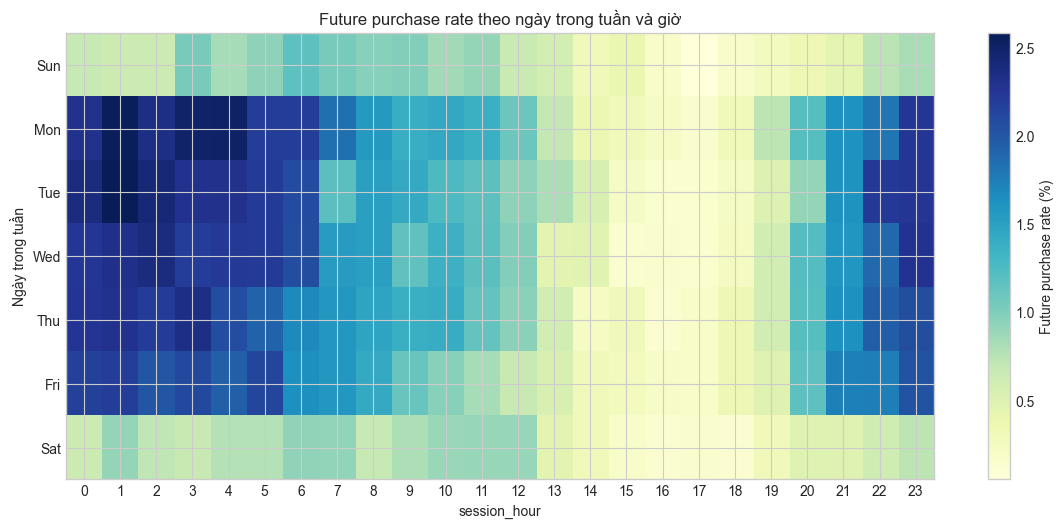

In [22]:
time_dow_hour_target_pd = (
    eda_time_labeled_df
    .groupBy("session_day_of_week", "session_hour")
    .agg(
        F.count(F.lit(1)).alias("labeled_session_count"),
        F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
    )
    .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
    .toPandas()
)
time_dow_hour_target_pd["day_name"] = time_dow_hour_target_pd["session_day_of_week"].map(day_name_map)

heatmap_rate_pd = (
    time_dow_hour_target_pd
    .pivot(index="day_name", columns="session_hour", values="future_purchase_rate_pct")
    .reindex(["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
    .reindex(columns=list(range(24)))
)

fig, ax = plt.subplots(figsize=(14, 5.8))
image = ax.imshow(heatmap_rate_pd.values, aspect="auto", cmap="YlGnBu")
ax.set_title("Future purchase rate theo ngày trong tuần và giờ")
ax.set_xlabel("session_hour")
ax.set_ylabel("Ngày trong tuần")
ax.set_xticks(range(24))
ax.set_yticks(range(len(heatmap_rate_pd.index)))
ax.set_yticklabels(heatmap_rate_pd.index)
fig.colorbar(image, ax=ax, label="Future purchase rate (%)")
plt.show()

Theo thời gian thì:
- Theo tháng thì không thực sự có xu hướng lặp lại(do dữ liệu cũng chưa đủ nhiều), ta chỉ thấy có xu hướng giảm xuống từ những tháng cuối năm, và tăng trở lại từ đầu năm đến giữa năm.
- Theo ngày trong tuần thì các ngày trong tuần tăng mạnh, các ngày cuối tuần rất ít các giao dịch có đồ được mua.
- Theo giờ trong ngày thì tỉ lệ mua tăng mạnh từ thời gian buổi tối(20h) mạnh nhất vào lúc nửa đêm và sau đó giảm dần cho đến ban ngày.

### 4.4. Nhóm `eda_traffic_df`

Nhóm này giữ các cột traffic/session acquisition để xem channel nào có future purchase rate cao, source nào mang lại revenue tốt và organic/direct/referral/paid khác nhau thế nào.

In [24]:
eda_traffic_columns = [
    "fullVisitorId",
    "visit_id",
    "channelGrouping_model",
    "traffic_source_clean_model",
    "traffic_medium_clean_model",
    "traffic_channel_type_model",
    "is_direct_traffic",
    "is_paid_traffic",
    "is_organic_traffic",
    "is_referral_traffic",
    "has_traffic_keyword",
    "has_gclid",
    "has_traffic_campaign",
    "has_traffic_ad_content",
    "has_referral_path",
]

eda_traffic_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_traffic_columns)
    .persist(StorageLevel.DISK_ONLY)
)

if "eda_base_keys_df" not in globals():
    eda_base_keys_columns = [
        "fullVisitorId",
        "visit_id",
        "session_date",
        "session_year",
        "session_month",
        "session_month_key",
        "has_full_30d_label_window",
    ]
    eda_base_keys_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_base_keys_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

if "eda_target_df" not in globals():
    eda_target_columns = [
        "fullVisitorId",
        "visit_id",
        "future_30d_has_purchase",
        "future_30d_revenue",
        "future_30d_purchase_count",
        "days_to_first_purchase",
        "has_full_30d_label_window",
    ]
    eda_target_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_target_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

eda_traffic_labeled_df = (
    eda_base_keys_df
    .join(eda_target_df.drop("has_full_30d_label_window"), on=["fullVisitorId", "visit_id"], how="left")
    .join(eda_traffic_df, on=["fullVisitorId", "visit_id"], how="left")
    .where(F.col("has_full_30d_label_window") == 1)
    .persist(StorageLevel.DISK_ONLY)
)

# Rebuild the working EDA table from stable group tables so rerunning this cell does not duplicate traffic columns.
eda_train_parts = [
    eda_base_keys_df,
    eda_target_df.drop("has_full_30d_label_window"),
]
if "eda_time_df" in globals():
    eda_train_parts.append(eda_time_df.select("fullVisitorId", "visit_id", "session_day_of_week", "session_hour"))
eda_train_parts.append(eda_traffic_df)

eda_train_df = eda_train_parts[0]
for one_part_df in eda_train_parts[1:]:
    eda_train_df = eda_train_df.join(one_part_df, on=["fullVisitorId", "visit_id"], how="left")
eda_train_df = eda_train_df.persist(StorageLevel.DISK_ONLY)
eda_labeled_train_df = eda_train_df.where(F.col("has_full_30d_label_window") == 1)

eda_traffic_df.printSchema()

root
 |-- fullVisitorId: string (nullable = true)
 |-- visit_id: long (nullable = true)
 |-- channelGrouping_model: string (nullable = true)
 |-- traffic_source_clean_model: string (nullable = true)
 |-- traffic_medium_clean_model: string (nullable = true)
 |-- traffic_channel_type_model: string (nullable = true)
 |-- is_direct_traffic: integer (nullable = true)
 |-- is_paid_traffic: integer (nullable = true)
 |-- is_organic_traffic: integer (nullable = true)
 |-- is_referral_traffic: integer (nullable = true)
 |-- has_traffic_keyword: integer (nullable = true)
 |-- has_gclid: integer (nullable = true)
 |-- has_traffic_campaign: integer (nullable = true)
 |-- has_traffic_ad_content: integer (nullable = true)
 |-- has_referral_path: integer (nullable = true)



In [25]:
traffic_flag_columns = [
    "is_direct_traffic",
    "is_paid_traffic",
    "is_organic_traffic",
    "is_referral_traffic",
    "has_traffic_keyword",
    "has_gclid",
    "has_traffic_campaign",
    "has_traffic_ad_content",
    "has_referral_path",
]

eda_traffic_overview_pd = eda_traffic_df.agg(
    F.count(F.lit(1)).alias("traffic_row_count"),
    F.countDistinct("fullVisitorId", "visit_id").alias("distinct_session_key_count"),
    F.sum(F.when(F.col("channelGrouping_model").isNull(), 1).otherwise(0)).alias("null_channel_grouping_model_sessions"),
    F.sum(F.when(F.col("traffic_source_clean_model").isNull(), 1).otherwise(0)).alias("null_traffic_source_model_sessions"),
    F.sum(F.when(F.col("traffic_channel_type_model").isNull(), 1).otherwise(0)).alias("null_traffic_channel_type_model_sessions"),
    F.countDistinct("channelGrouping_model").alias("channel_grouping_cardinality"),
    F.countDistinct("traffic_source_clean_model").alias("traffic_source_cardinality"),
    F.countDistinct("traffic_medium_clean_model").alias("traffic_medium_cardinality"),
    F.countDistinct("traffic_channel_type_model").alias("traffic_channel_type_cardinality"),
).toPandas()

display(eda_traffic_overview_pd)

,traffic_row_count,distinct_session_key_count,null_channel_grouping_model_sessions,null_traffic_source_model_sessions,null_traffic_channel_type_model_sessions,channel_grouping_cardinality,traffic_source_cardinality,traffic_medium_cardinality,traffic_channel_type_cardinality
0,1706613,1706613,0,0,0,8,44,7,5


In [26]:
def build_traffic_group_summary(group_column, min_sessions=0):
    summary_df = (
        eda_traffic_labeled_df
        .groupBy(group_column)
        .agg(
            F.count(F.lit(1)).alias("labeled_session_count"),
            F.countDistinct("fullVisitorId").alias("user_count"),
            F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
            F.sum(F.coalesce(F.col("future_30d_revenue"), F.lit(0.0))).alias("total_future_30d_revenue"),
            F.round(F.avg("future_30d_revenue"), 4).alias("avg_future_30d_revenue"),
            F.round(F.expr("percentile_approx(future_30d_revenue, 0.99, 10000)"), 4).alias("p99_future_30d_revenue"),
        )
        .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
        .withColumn("revenue_per_session", F.round(F.col("total_future_30d_revenue") / F.col("labeled_session_count"), 4))
        .where(F.col("labeled_session_count") >= F.lit(min_sessions))
    )
    return summary_df

traffic_channel_summary_pd = (
    build_traffic_group_summary("traffic_channel_type_model")
    .orderBy(F.desc("future_purchase_rate_pct"), F.desc("labeled_session_count"))
    .toPandas()
)

channel_grouping_summary_pd = (
    build_traffic_group_summary("channelGrouping_model")
    .orderBy(F.desc("future_purchase_rate_pct"), F.desc("labeled_session_count"))
    .toPandas()
)

display(traffic_channel_summary_pd)
display(channel_grouping_summary_pd)

,traffic_channel_type_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,other,8975,5878,469,3065941.58,341.6091,5391.49,5.2256,341.6091
1,direct,545263,392021,15075,4825574.41,8.8500,113.77,2.7647,8.8500
2,organic_search,553934,456031,4473,950812.92,1.7165,0.00,0.8075,1.7165
3,paid_search,73594,52791,576,96486.89,1.3111,0.00,0.7827,1.3111
4,referral,442312,395381,676,143163.82,0.3237,0.00,0.1528,0.3237


,channelGrouping_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,referral,199379,123096,10007,1841781.50,9.2376,210.46,5.0191,9.2376
1,paid search,43866,32425,790,126414.66,2.8818,46.87,1.8009,2.8818
2,direct,259095,197838,4039,2708398.97,10.4533,60.75,1.5589,10.4533
3,display,50898,35094,470,3065859.07,60.2354,0.00,0.9234,60.2354
4,organic search,700971,571764,5793,1325522.53,1.8910,0.00,0.8264,1.8910
5,other,131,99,1,133.12,1.0162,0.00,0.7634,1.0162
6,affiliates,29963,24192,22,545.77,0.0182,0.00,0.0734,0.0182
7,social,339775,316560,147,13324.00,0.0392,0.00,0.0433,0.0392


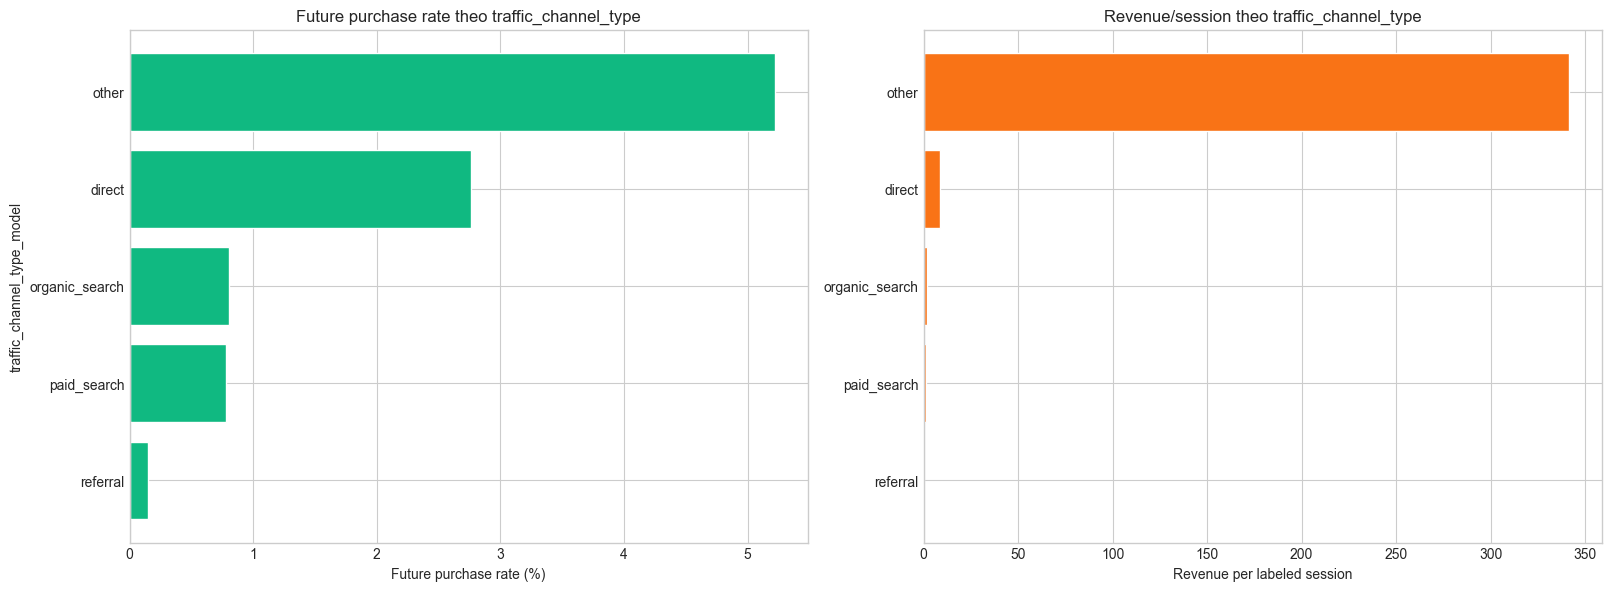

In [27]:
traffic_channel_plot_pd = traffic_channel_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), constrained_layout=True)

axes[0].barh(
    traffic_channel_plot_pd["traffic_channel_type_model"],
    traffic_channel_plot_pd["future_purchase_rate_pct"],
    color="#10B981",
    edgecolor="white",
)
axes[0].set_title("Future purchase rate theo traffic_channel_type")
axes[0].set_xlabel("Future purchase rate (%)")
axes[0].set_ylabel("traffic_channel_type_model")

axes[1].barh(
    traffic_channel_plot_pd["traffic_channel_type_model"],
    traffic_channel_plot_pd["revenue_per_session"],
    color="#F97316",
    edgecolor="white",
)
axes[1].set_title("Revenue/session theo traffic_channel_type")
axes[1].set_xlabel("Revenue per labeled session")
axes[1].set_ylabel("")

plt.show()

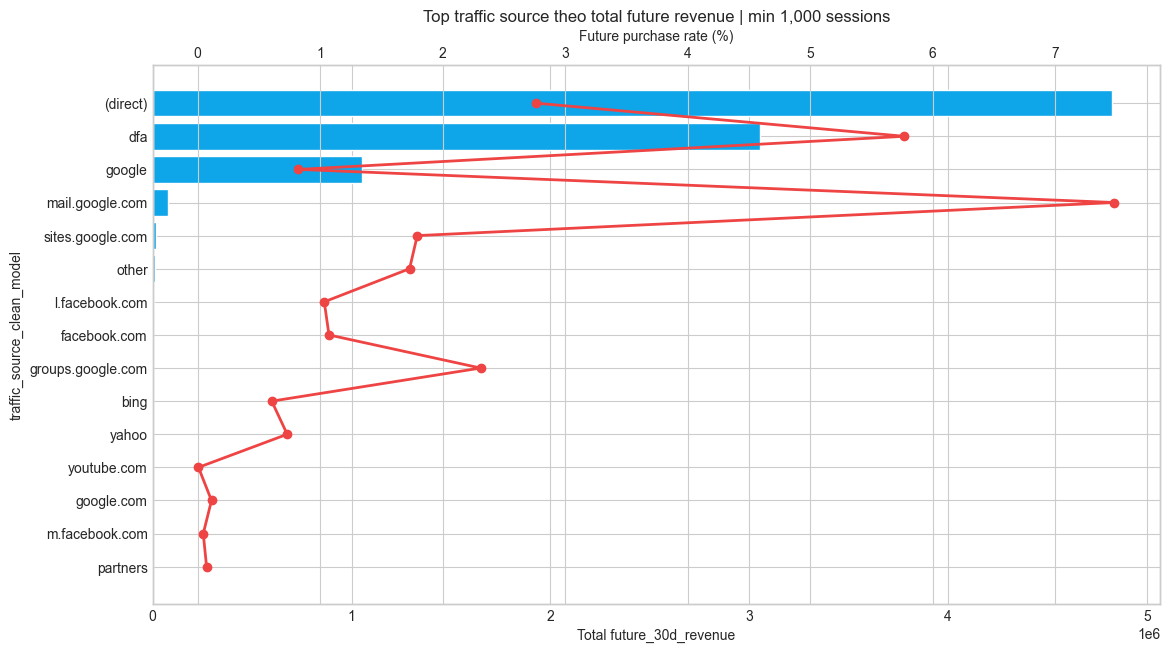

,traffic_source_clean_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,(direct),545263,392021,15075,4825574.41,8.8500,114.17,2.7647,8.8500
1,dfa,6587,4285,380,3054673.25,463.7427,12638.54,5.7689,463.7427
2,google,619050,495809,5097,1055064.91,1.7043,0.00,0.8234,1.7043
3,mail.google.com,2419,1399,181,77746.95,32.1401,829.00,7.4824,32.1401
4,sites.google.com,8199,5429,147,18130.60,2.2113,60.57,1.7929,2.2113
5,other,4335,3605,75,12310.35,2.8398,36.98,1.7301,2.8398
6,l.facebook.com,1451,1150,15,4534.56,3.1251,17.68,1.0338,3.1251
7,facebook.com,3450,2692,37,3492.47,1.0123,22.80,1.0725,1.0123
8,groups.google.com,1775,1276,41,2236.83,1.2602,38.59,2.3099,1.2602
9,bing,3139,2495,19,1993.61,0.6351,0.00,0.6053,0.6351


In [28]:
source_min_sessions = 1000
traffic_source_summary_pd = (
    build_traffic_group_summary("traffic_source_clean_model", min_sessions=source_min_sessions)
    .orderBy(F.desc("total_future_30d_revenue"), F.desc("future_purchase_rate_pct"))
    .limit(15)
    .toPandas()
)

traffic_source_plot_pd = traffic_source_summary_pd.sort_values("total_future_30d_revenue", ascending=True)

fig, ax1 = plt.subplots(figsize=(13, 7))
ax1.barh(
    traffic_source_plot_pd["traffic_source_clean_model"],
    traffic_source_plot_pd["total_future_30d_revenue"],
    color="#0EA5E9",
    edgecolor="white",
    label="Total future revenue",
)
ax1.set_title(f"Top traffic source theo total future revenue | min {source_min_sessions:,} sessions")
ax1.set_xlabel("Total future_30d_revenue")
ax1.set_ylabel("traffic_source_clean_model")

ax2 = ax1.twiny()
ax2.plot(
    traffic_source_plot_pd["future_purchase_rate_pct"],
    traffic_source_plot_pd["traffic_source_clean_model"],
    color="#EF4444",
    marker="o",
    linewidth=2,
    label="Future purchase rate",
)
ax2.set_xlabel("Future purchase rate (%)")

plt.show()

display(traffic_source_summary_pd)

- Màu xanh là tổng doanh thu
- Màu đỏ là tỉ lệ session có purchase

Phân tích:
- Nhóm direct có doanh thu cao nhất 4.8M, dù tỉ lệ purchase rất thấp 2.8%.
- Nhóm dfa đứng thứu 2 về doanh thu, và tỉ lệ purchase cũng cao, khoảng 5.8%
- mail.google.com có tổng revenue nhỏ hơn nhiều, nhưng purchase rate cao nhất, khoảng 7%+. Cho thấy chất lượng tốt hơn vì ít session hơn nhưng tỉ lệ lại cao hơn.
- google có revenue khá lớn nhưng purchase rate thấp, khoảng 1%. Source này có thể mang nhiều traffic nhưng chất lượng mua thấp hơn.
- Các nhóm còn lại chiếm một phần tỉ lệ nhưng gần như không mang lại doanh thu. 


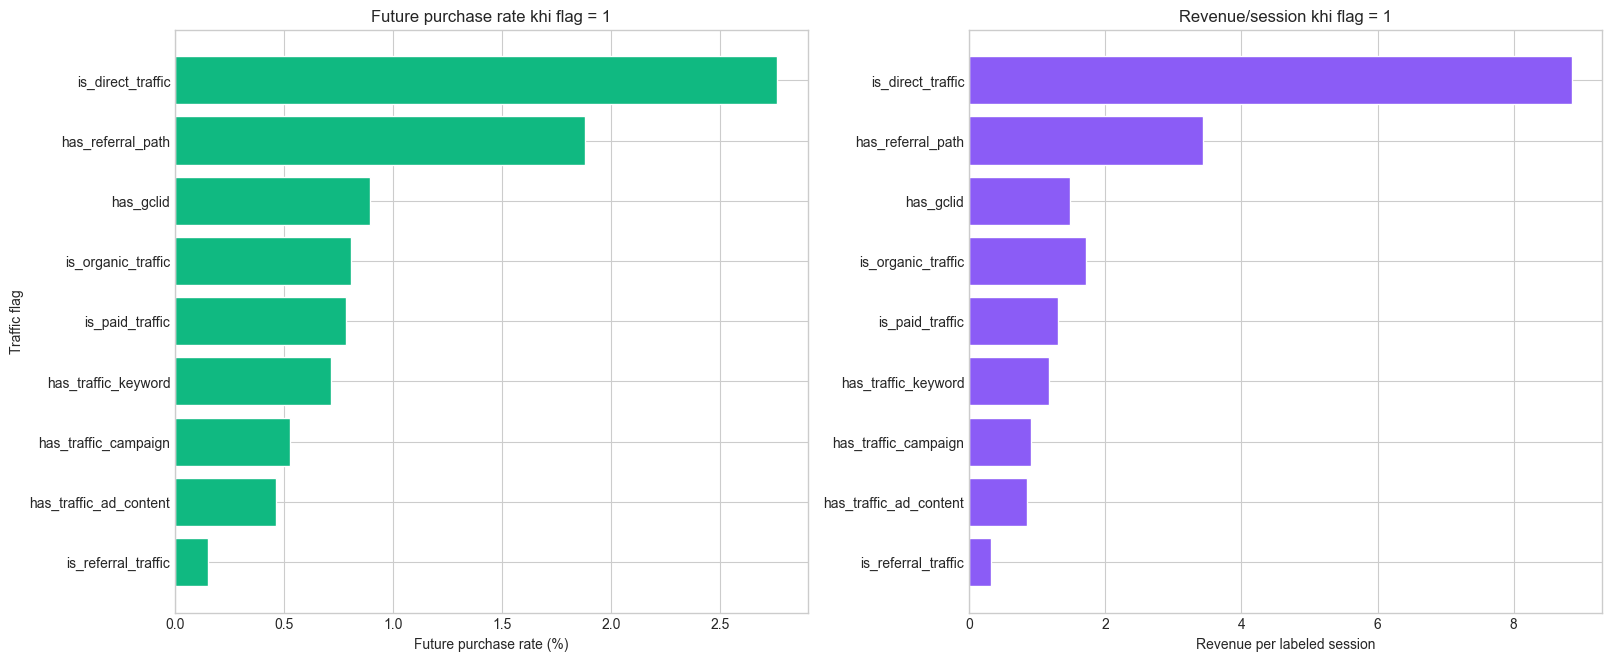

,flag_value,labeled_session_count,future_purchase_sessions,total_future_30d_revenue,future_purchase_rate_pct,revenue_per_session,flag
11,0,1549040,20599,8970594.86,1.3298,5.7911,has_gclid
10,1,75038,670,111384.76,0.8929,1.4844,has_gclid
17,0,1084938,11115,7226874.12,1.0245,6.6611,has_referral_path
16,1,539140,10154,1855105.50,1.8834,3.4409,has_referral_path
15,0,1561573,20980,9028506.72,1.3435,5.7817,has_traffic_ad_content
14,1,62505,289,53472.90,0.4624,0.8555,has_traffic_ad_content
13,0,1524421,20743,8991144.35,1.3607,5.8981,has_traffic_campaign
12,1,99657,526,90835.27,0.5278,0.9115,has_traffic_campaign
9,0,1539784,20665,8983651.50,1.3421,5.8344,has_traffic_keyword
8,1,84294,604,98328.12,0.7165,1.1665,has_traffic_keyword


In [29]:
traffic_flag_summary_dfs = []
for flag_column in traffic_flag_columns:
    one_flag_df = (
        eda_traffic_labeled_df
        .groupBy(F.col(flag_column).cast("int").alias("flag_value"))
        .agg(
            F.count(F.lit(1)).alias("labeled_session_count"),
            F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
            F.sum(F.coalesce(F.col("future_30d_revenue"), F.lit(0.0))).alias("total_future_30d_revenue"),
        )
        .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
        .withColumn("revenue_per_session", F.round(F.col("total_future_30d_revenue") / F.col("labeled_session_count"), 4))
        .withColumn("flag", F.lit(flag_column))
    )
    traffic_flag_summary_dfs.append(one_flag_df)

traffic_flag_summary_df = traffic_flag_summary_dfs[0]
for one_flag_df in traffic_flag_summary_dfs[1:]:
    traffic_flag_summary_df = traffic_flag_summary_df.unionByName(one_flag_df)

traffic_flag_summary_pd = traffic_flag_summary_df.toPandas()
traffic_flag_positive_pd = (
    traffic_flag_summary_pd[traffic_flag_summary_pd["flag_value"] == 1]
    .sort_values("future_purchase_rate_pct", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)

axes[0].barh(
    traffic_flag_positive_pd["flag"],
    traffic_flag_positive_pd["future_purchase_rate_pct"],
    color="#10B981",
    edgecolor="white",
)
axes[0].set_title("Future purchase rate khi flag = 1")
axes[0].set_xlabel("Future purchase rate (%)")
axes[0].set_ylabel("Traffic flag")

axes[1].barh(
    traffic_flag_positive_pd["flag"],
    traffic_flag_positive_pd["revenue_per_session"],
    color="#8B5CF6",
    edgecolor="white",
)
axes[1].set_title("Revenue/session khi flag = 1")
axes[1].set_xlabel("Revenue per labeled session")
axes[1].set_ylabel("")

plt.show()

display(traffic_flag_summary_pd.sort_values(["flag", "flag_value"]))

Nhìn vào đây ta thấy, tỉ lệ doanh thu khá tương quan với tỉ lệ mua ở mỗi thuộc tính
- Chiếm nhiều nhất về cả tỉ lệ mua lẫn doanh thu là is_direct_traffic: session đến trực tiếp
- Tiếp đến là được người khác giới thiệu has_referral_path, đứng thứ 2 về cả doanh thu và tỉ lệ.
- Các giá trị còn lại thì giảm dần từ has_gclid, is_organic_traffic, ....

### 4.5. Nhóm `eda_device_df`

Nhóm này giữ các cột thiết bị/browser/OS để xem thiết bị có ảnh hưởng tới future purchase rate và future revenue hay không.

In [30]:
eda_device_columns = [
    "fullVisitorId",
    "visit_id",
    "device_category_model",
    "device_is_mobile",
    "browser_family_model",
    "os_family_model",
]

eda_device_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_device_columns)
    .persist(StorageLevel.DISK_ONLY)
)

if "eda_base_keys_df" not in globals():
    eda_base_keys_columns = [
        "fullVisitorId",
        "visit_id",
        "session_date",
        "session_year",
        "session_month",
        "session_month_key",
        "has_full_30d_label_window",
    ]
    eda_base_keys_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_base_keys_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

if "eda_target_df" not in globals():
    eda_target_columns = [
        "fullVisitorId",
        "visit_id",
        "future_30d_has_purchase",
        "future_30d_revenue",
        "future_30d_purchase_count",
        "days_to_first_purchase",
        "has_full_30d_label_window",
    ]
    eda_target_df = (
        read_clean_selected_columns(TRAIN_CLEAN_PATH, eda_target_columns)
        .persist(StorageLevel.DISK_ONLY)
    )

eda_device_labeled_df = (
    eda_base_keys_df
    .join(eda_target_df.drop("has_full_30d_label_window"), on=["fullVisitorId", "visit_id"], how="left")
    .join(eda_device_df, on=["fullVisitorId", "visit_id"], how="left")
    .where(F.col("has_full_30d_label_window") == 1)
    .persist(StorageLevel.DISK_ONLY)
)

# Rebuild the working EDA table from stable group tables so rerunning this cell does not duplicate device columns.
eda_train_parts = [
    eda_base_keys_df,
    eda_target_df.drop("has_full_30d_label_window"),
]
if "eda_time_df" in globals():
    eda_train_parts.append(eda_time_df.select("fullVisitorId", "visit_id", "session_day_of_week", "session_hour"))
if "eda_traffic_df" in globals():
    eda_train_parts.append(eda_traffic_df)
eda_train_parts.append(eda_device_df)

eda_train_df = eda_train_parts[0]
for one_part_df in eda_train_parts[1:]:
    eda_train_df = eda_train_df.join(one_part_df, on=["fullVisitorId", "visit_id"], how="left")
eda_train_df = eda_train_df.persist(StorageLevel.DISK_ONLY)
eda_labeled_train_df = eda_train_df.where(F.col("has_full_30d_label_window") == 1)

eda_device_df.printSchema()

root
 |-- fullVisitorId: string (nullable = true)
 |-- visit_id: long (nullable = true)
 |-- device_category_model: string (nullable = true)
 |-- device_is_mobile: boolean (nullable = true)
 |-- browser_family_model: string (nullable = true)
 |-- os_family_model: string (nullable = true)



In [31]:
eda_device_overview_pd = eda_device_df.agg(
    F.count(F.lit(1)).alias("device_row_count"),
    F.countDistinct("fullVisitorId", "visit_id").alias("distinct_session_key_count"),
    F.sum(F.when(F.col("device_category_model").isNull(), 1).otherwise(0)).alias("null_device_category_sessions"),
    F.sum(F.when(F.col("device_is_mobile").isNull(), 1).otherwise(0)).alias("null_device_is_mobile_sessions"),
    F.sum(F.when(F.col("browser_family_model").isNull(), 1).otherwise(0)).alias("null_browser_family_sessions"),
    F.sum(F.when(F.col("os_family_model").isNull(), 1).otherwise(0)).alias("null_os_family_sessions"),
    F.countDistinct("device_category_model").alias("device_category_cardinality"),
    F.countDistinct("browser_family_model").alias("browser_family_cardinality"),
    F.countDistinct("os_family_model").alias("os_family_cardinality"),
).toPandas()

display(eda_device_overview_pd)

,device_row_count,distinct_session_key_count,null_device_category_sessions,null_device_is_mobile_sessions,null_browser_family_sessions,null_os_family_sessions,device_category_cardinality,browser_family_cardinality,os_family_cardinality
0,1706613,1706613,0,0,0,0,3,6,6


In [32]:
def build_device_group_summary(group_column, min_sessions=0):
    summary_df = (
        eda_device_labeled_df
        .groupBy(group_column)
        .agg(
            F.count(F.lit(1)).alias("labeled_session_count"),
            F.countDistinct("fullVisitorId").alias("user_count"),
            F.sum(F.when(F.col("future_30d_has_purchase") == 1, 1).otherwise(0)).alias("future_purchase_sessions"),
            F.sum(F.coalesce(F.col("future_30d_revenue"), F.lit(0.0))).alias("total_future_30d_revenue"),
            F.round(F.avg("future_30d_revenue"), 4).alias("avg_future_30d_revenue"),
            F.round(F.expr("percentile_approx(future_30d_revenue, 0.99, 10000)"), 4).alias("p99_future_30d_revenue"),
        )
        .withColumn("future_purchase_rate_pct", F.round(F.col("future_purchase_sessions") / F.col("labeled_session_count") * 100, 4))
        .withColumn("revenue_per_session", F.round(F.col("total_future_30d_revenue") / F.col("labeled_session_count"), 4))
        .where(F.col("labeled_session_count") >= F.lit(min_sessions))
    )
    return summary_df

device_category_summary_pd = (
    build_device_group_summary("device_category_model")
    .orderBy(F.desc("future_purchase_rate_pct"), F.desc("labeled_session_count"))
    .toPandas()
)

mobile_summary_pd = (
    build_device_group_summary("device_is_mobile")
    .orderBy("device_is_mobile")
    .toPandas()
)
mobile_summary_pd["device_is_mobile_label"] = mobile_summary_pd["device_is_mobile"].map({False: "not_mobile", True: "mobile", 0: "not_mobile", 1: "mobile"})

browser_family_summary_pd = (
    build_device_group_summary("browser_family_model", min_sessions=1000)
    .orderBy(F.desc("future_purchase_rate_pct"), F.desc("labeled_session_count"))
    .toPandas()
)

os_family_summary_pd = (
    build_device_group_summary("os_family_model", min_sessions=1000)
    .orderBy(F.desc("future_purchase_rate_pct"), F.desc("labeled_session_count"))
    .toPandas()
)

display(device_category_summary_pd)
display(mobile_summary_pd)
display(browser_family_summary_pd)
display(os_family_summary_pd)

,device_category_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,desktop,1113235,857112,19843,8952147.29,8.0416,62.98,1.7825,8.0416
1,tablet,62444,49984,184,13176.47,0.2110,0.00,0.2947,0.2110
2,mobile,448399,355243,1242,116655.86,0.2602,0.00,0.2770,0.2602


,device_is_mobile,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session,device_is_mobile_label
0,False,1113334,857327,19844,8952165.28,8.0409,62.97,1.7824,8.0409,not_mobile
1,True,510744,405391,1425,129814.34,0.2542,0.00,0.2790,0.2542,mobile


,browser_family_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,chrome,1112272,825781,19563,4615272.15,4.1494,61.27,1.7588,4.1494
1,firefox,61078,51511,422,4307947.32,70.5319,0.00,0.6909,70.5319
2,internet explorer,34051,30937,197,36221.43,1.0637,0.00,0.5785,1.0637
3,safari,313963,265954,1028,117105.67,0.3730,0.00,0.3274,0.3730
4,edge,19358,16535,42,4998.70,0.2582,0.00,0.2170,0.2582
5,other,83356,71940,17,434.35,0.0052,0.00,0.0204,0.0052


,os_family_model,labeled_session_count,user_count,future_purchase_sessions,total_future_30d_revenue,avg_future_30d_revenue,p99_future_30d_revenue,future_purchase_rate_pct,revenue_per_session
0,other,61276,44649,2037,534948.53,8.7301,198.85,3.3243,8.7301
1,mac os,416746,295641,12478,2708974.55,6.5003,129.17,2.9941,6.5003
2,linux,60844,43240,1273,93563.68,1.5378,49.99,2.0922,1.5378
3,windows,591148,489314,4070,5615587.01,9.4995,0.00,0.6885,9.4995
4,ios,209506,167422,668,33791.67,0.1613,0.00,0.3188,0.1613
5,android,284558,222559,743,95114.18,0.3343,0.00,0.2611,0.3343


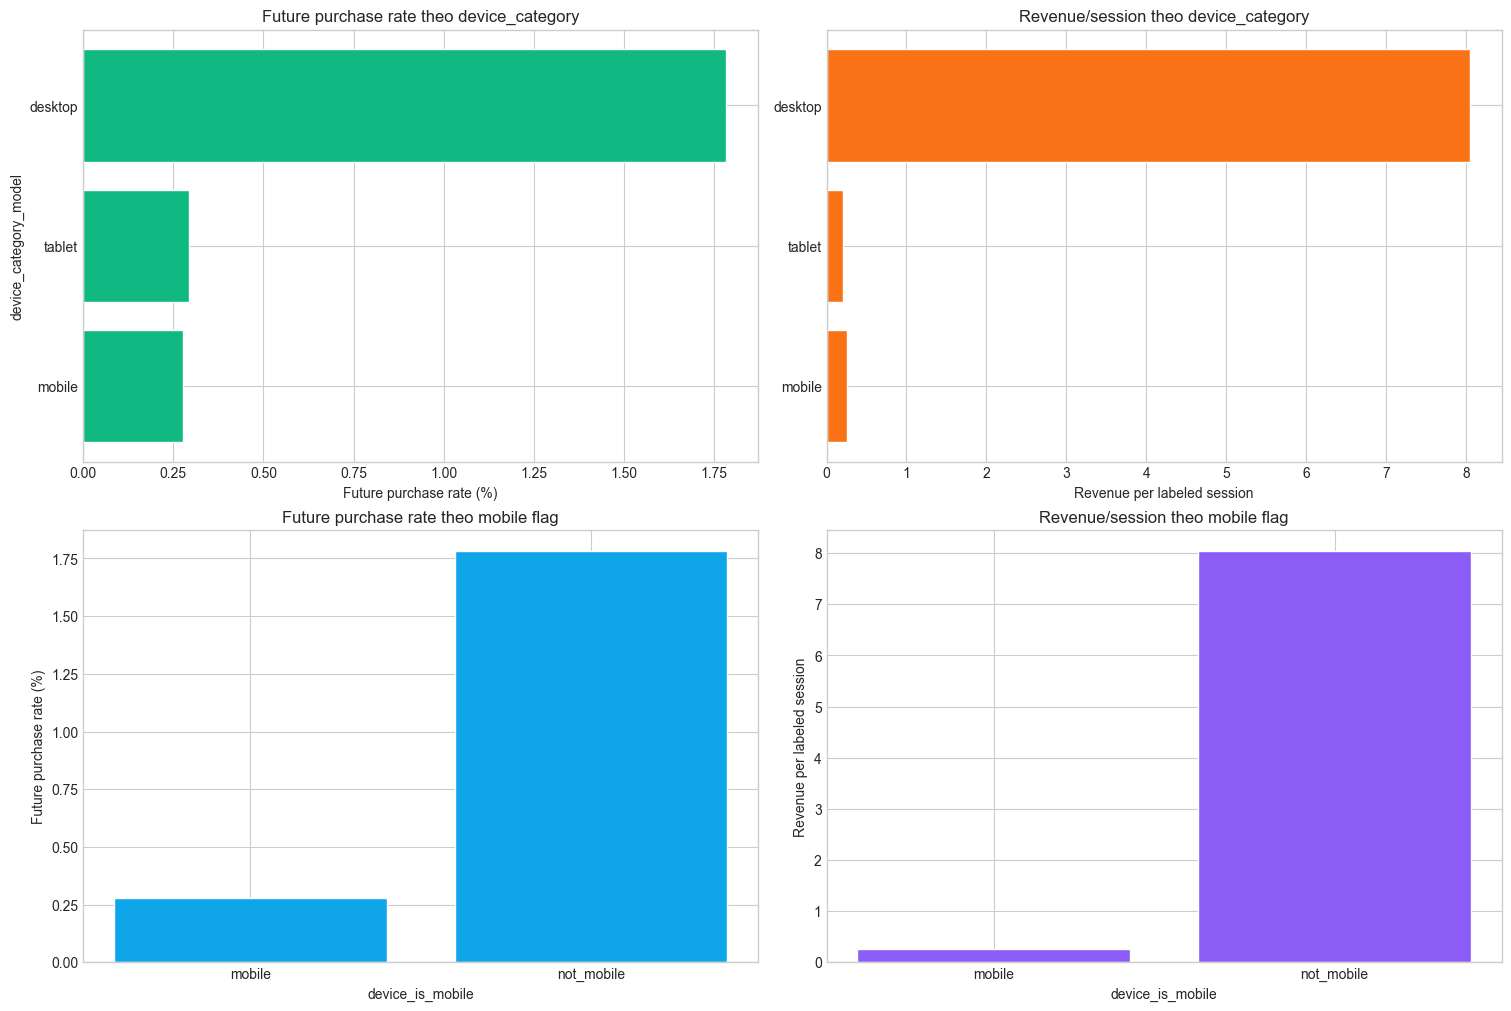

In [33]:
device_category_plot_pd = device_category_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)
mobile_plot_pd = mobile_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

axes[0, 0].barh(
    device_category_plot_pd["device_category_model"],
    device_category_plot_pd["future_purchase_rate_pct"],
    color="#10B981",
    edgecolor="white",
)
axes[0, 0].set_title("Future purchase rate theo device_category")
axes[0, 0].set_xlabel("Future purchase rate (%)")
axes[0, 0].set_ylabel("device_category_model")

axes[0, 1].barh(
    device_category_plot_pd["device_category_model"],
    device_category_plot_pd["revenue_per_session"],
    color="#F97316",
    edgecolor="white",
)
axes[0, 1].set_title("Revenue/session theo device_category")
axes[0, 1].set_xlabel("Revenue per labeled session")
axes[0, 1].set_ylabel("")

axes[1, 0].bar(
    mobile_plot_pd["device_is_mobile_label"],
    mobile_plot_pd["future_purchase_rate_pct"],
    color="#0EA5E9",
    edgecolor="white",
)
axes[1, 0].set_title("Future purchase rate theo mobile flag")
axes[1, 0].set_ylabel("Future purchase rate (%)")
axes[1, 0].set_xlabel("device_is_mobile")

axes[1, 1].bar(
    mobile_plot_pd["device_is_mobile_label"],
    mobile_plot_pd["revenue_per_session"],
    color="#8B5CF6",
    edgecolor="white",
)
axes[1, 1].set_title("Revenue/session theo mobile flag")
axes[1, 1].set_ylabel("Revenue per labeled session")
axes[1, 1].set_xlabel("device_is_mobile")

plt.show()

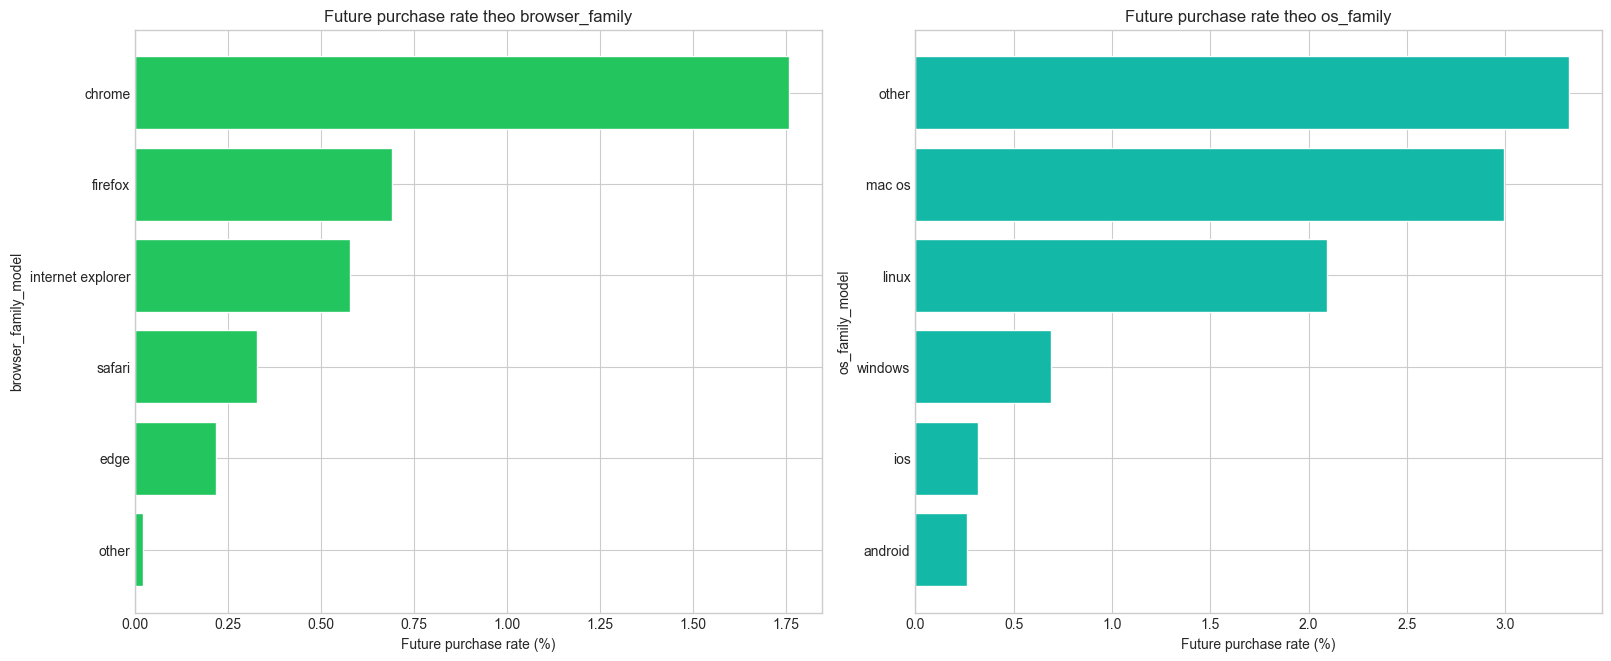

In [34]:
browser_plot_pd = browser_family_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)
os_plot_pd = os_family_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)

axes[0].barh(
    browser_plot_pd["browser_family_model"],
    browser_plot_pd["future_purchase_rate_pct"],
    color="#22C55E",
    edgecolor="white",
)
axes[0].set_title("Future purchase rate theo browser_family")
axes[0].set_xlabel("Future purchase rate (%)")
axes[0].set_ylabel("browser_family_model")

axes[1].barh(
    os_plot_pd["os_family_model"],
    os_plot_pd["future_purchase_rate_pct"],
    color="#14B8A6",
    edgecolor="white",
)
axes[1].set_title("Future purchase rate theo os_family")
axes[1].set_xlabel("Future purchase rate (%)")
axes[1].set_ylabel("os_family_model")

plt.show()

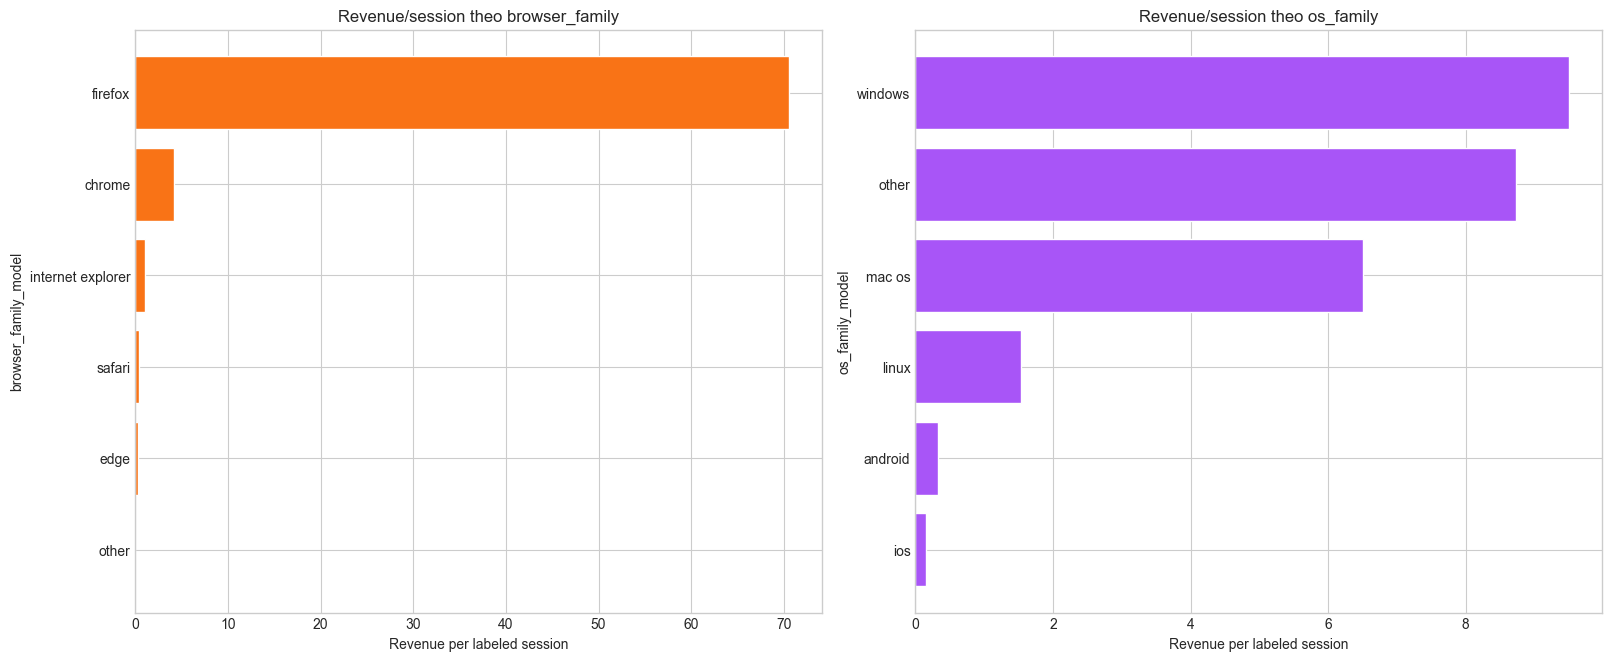

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)

browser_revenue_plot_pd = browser_family_summary_pd.sort_values("revenue_per_session", ascending=True)
os_revenue_plot_pd = os_family_summary_pd.sort_values("revenue_per_session", ascending=True)

axes[0].barh(
    browser_revenue_plot_pd["browser_family_model"],
    browser_revenue_plot_pd["revenue_per_session"],
    color="#F97316",
    edgecolor="white",
)
axes[0].set_title("Revenue/session theo browser_family")
axes[0].set_xlabel("Revenue per labeled session")
axes[0].set_ylabel("browser_family_model")

axes[1].barh(
    os_revenue_plot_pd["os_family_model"],
    os_revenue_plot_pd["revenue_per_session"],
    color="#A855F7",
    edgecolor="white",
)
axes[1].set_title("Revenue/session theo os_family")
axes[1].set_xlabel("Revenue per labeled session")
axes[1].set_ylabel("os_family_model")

plt.show()

Khi đọc nhóm thiết bị, cần xem cả purchase rate, revenue/session và volume. Browser hoặc OS có rate cao nhưng ít session có thể chỉ là nhiễu; `device_category_model` và `device_is_mobile` thường là hai lát cắt ổn định hơn để cân nhắc feature.

## 4.6. Nhom geo: quoc gia, khu vuc va muc do lech traffic

In [2]:
spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", "8")
spark.conf.set("spark.sql.adaptive.enabled", "false")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

geo_columns = [
    "fullVisitorId",
    "visit_id",
    "geo_country_model",
    "geo_continent",
    "geo_sub_continent",
    "has_geo_region",
    "has_geo_metro",
]

geo_target_columns = [
    "fullVisitorId",
    "visit_id",
    "future_30d_has_purchase",
    "future_30d_revenue",
    "future_30d_purchase_count",
    "days_to_first_purchase",
    "has_full_30d_label_window",
]

geo_base_key_columns = [
    "fullVisitorId",
    "visit_id",
    "session_date",
    "session_year",
    "session_month",
    "session_month_key",
    "has_full_30d_label_window",
]

geo_analysis_columns = list(dict.fromkeys(geo_target_columns + geo_columns))

eda_geo_analysis_df = read_clean_selected_columns(TRAIN_CLEAN_PATH, geo_analysis_columns)
eda_geo_df = eda_geo_analysis_df.select(*geo_columns)

if "eda_base_keys_df" not in globals():
    eda_base_keys_df = read_clean_selected_columns(TRAIN_CLEAN_PATH, geo_base_key_columns)

if "eda_target_df" not in globals():
    eda_target_df = eda_geo_analysis_df.select(*geo_target_columns)

eda_geo_labeled_df = (
    eda_geo_analysis_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select(*(geo_target_columns + geo_columns[2:]))
)

print("eda_geo_df ready")
print("eda_geo_labeled_df ready")
print("Geo EDA is intentionally built without joins/deduplicate to keep Spark local stable.")

eda_geo_df ready
eda_geo_labeled_df ready
Geo EDA is intentionally built without joins/deduplicate to keep Spark local stable.


In [3]:
geo_validation_row = eda_geo_labeled_df.agg(
    F.count("*").alias("labeled_sessions"),
    F.avg("future_30d_has_purchase").alias("future_purchase_rate"),
    F.sum("future_30d_revenue").alias("total_future_30d_revenue"),
).collect()[0].asDict()

geo_validation_pd = pd.DataFrame([geo_validation_row])

geo_validation_pd["future_purchase_rate_pct"] = geo_validation_pd["future_purchase_rate"] * 100
display(geo_validation_pd)

,labeled_sessions,future_purchase_rate,total_future_30d_revenue,future_purchase_rate_pct
0,1624078,0.013096,9081979.62,1.309605


In [4]:
def build_geo_group_summary(group_column, top_n=15, min_sessions=50, order_by="labeled_session_count"):
    summary_df = (
        eda_geo_labeled_df
        .withColumn(group_column, F.coalesce(F.col(group_column).cast("string"), F.lit("(missing)")))
        .groupBy(group_column)
        .agg(
            F.count("*").alias("labeled_session_count"),
            F.avg("future_30d_has_purchase").alias("future_purchase_rate"),
            F.sum("future_30d_revenue").alias("total_future_30d_revenue"),
            F.avg("future_30d_revenue").alias("revenue_per_session"),
        )
        .withColumn("future_purchase_rate_pct", F.col("future_purchase_rate") * 100)
        .where(F.col("labeled_session_count") >= min_sessions)
        .orderBy(F.desc(order_by))
        .limit(top_n)
    )
    return pd.DataFrame([row.asDict() for row in summary_df.collect()])

country_volume_pd = build_geo_group_summary("geo_country_model", top_n=15, min_sessions=50, order_by="labeled_session_count")
country_revenue_pd = build_geo_group_summary("geo_country_model", top_n=15, min_sessions=50, order_by="total_future_30d_revenue")
continent_summary_pd = build_geo_group_summary("geo_continent", top_n=20, min_sessions=50, order_by="labeled_session_count")
subcontinent_summary_pd = build_geo_group_summary("geo_sub_continent", top_n=15, min_sessions=50, order_by="labeled_session_count")

display(country_volume_pd)
display(country_revenue_pd.head(10))

,geo_country_model,labeled_session_count,future_purchase_rate,total_future_30d_revenue,revenue_per_session,future_purchase_rate_pct
0,united states,682111,0.029542,8807226.30,12.911720,2.954211
1,india,99136,0.000262,2360.39,0.023810,0.026227
2,united kingdom,70105,0.000514,3436.09,0.049013,0.051352
3,canada,48667,0.007315,100679.25,2.068738,0.731502
4,germany,36733,0.000163,369.34,0.010055,0.016334
5,japan,34060,0.000822,12886.62,0.378351,0.082208
6,vietnam,34060,0.000029,37.49,0.001101,0.002936
7,brazil,33561,0.001013,4013.11,0.119577,0.101308
8,france,30387,0.000329,1452.07,0.047786,0.032909
9,thailand,28949,0.000622,1934.22,0.066815,0.062178


,geo_country_model,labeled_session_count,future_purchase_rate,total_future_30d_revenue,revenue_per_session,future_purchase_rate_pct
0,united states,682111,0.029542,8807226.30,12.911720,2.954211
1,canada,48667,0.007315,100679.25,2.068738,0.731502
2,venezuela,2861,0.028661,52462.31,18.337053,2.866131
3,kenya,1355,0.009594,24074.10,17.766863,0.959410
4,japan,34060,0.000822,12886.62,0.378351,0.082208
5,taiwan,24958,0.002604,10084.98,0.404078,0.260438
6,singapore,12553,0.005258,6454.05,0.514144,0.525771
7,australia,22346,0.001522,5675.37,0.253977,0.152153
8,mexico,24342,0.001027,5616.38,0.230728,0.102703
9,indonesia,16052,0.000810,5292.09,0.329684,0.080987


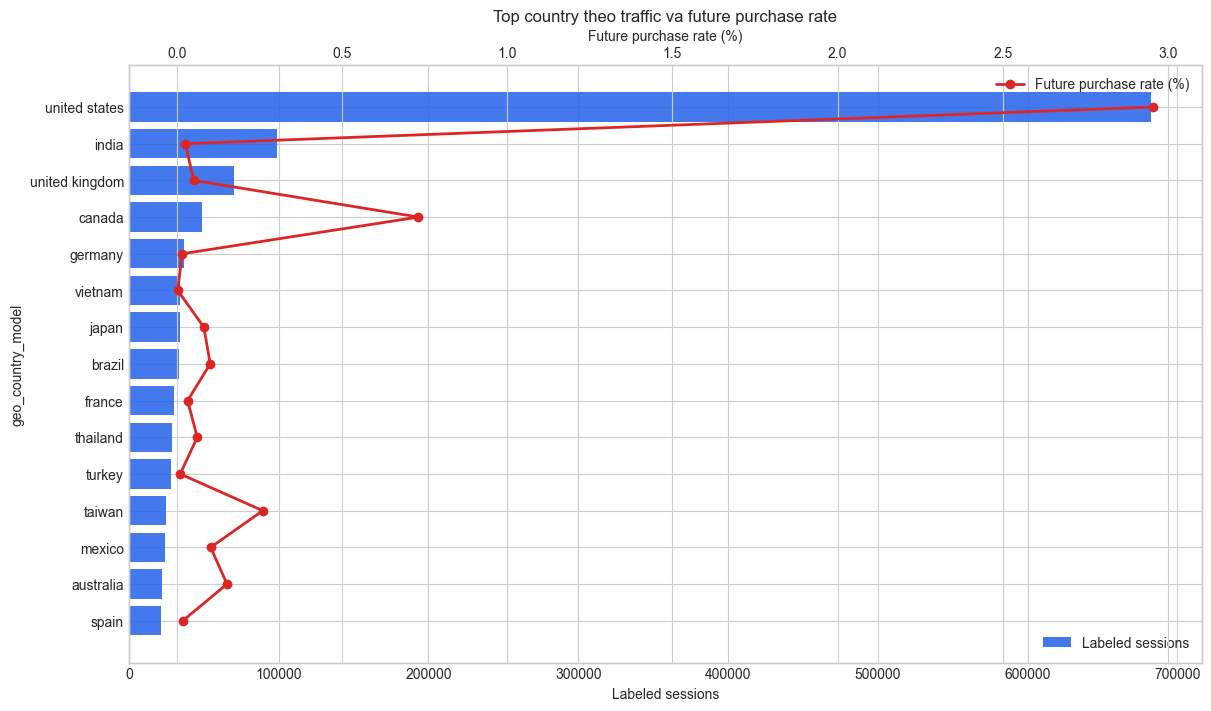

In [5]:
country_volume_plot_pd = country_volume_pd.sort_values("labeled_session_count", ascending=True)

fig, ax1 = plt.subplots(figsize=(12, 7), constrained_layout=True)
ax1.barh(
    country_volume_plot_pd["geo_country_model"],
    country_volume_plot_pd["labeled_session_count"],
    color="#2563EB",
    alpha=0.86,
    label="Labeled sessions",
)
ax1.set_title("Top country theo traffic va future purchase rate")
ax1.set_xlabel("Labeled sessions")
ax1.set_ylabel("geo_country_model")

ax2 = ax1.twiny()
ax2.plot(
    country_volume_plot_pd["future_purchase_rate_pct"],
    country_volume_plot_pd["geo_country_model"],
    color="#DC2626",
    marker="o",
    linewidth=2,
    label="Future purchase rate (%)",
)
ax2.set_xlabel("Future purchase rate (%)")

ax1.legend(loc="lower right")
ax2.legend(loc="upper right")
plt.show()

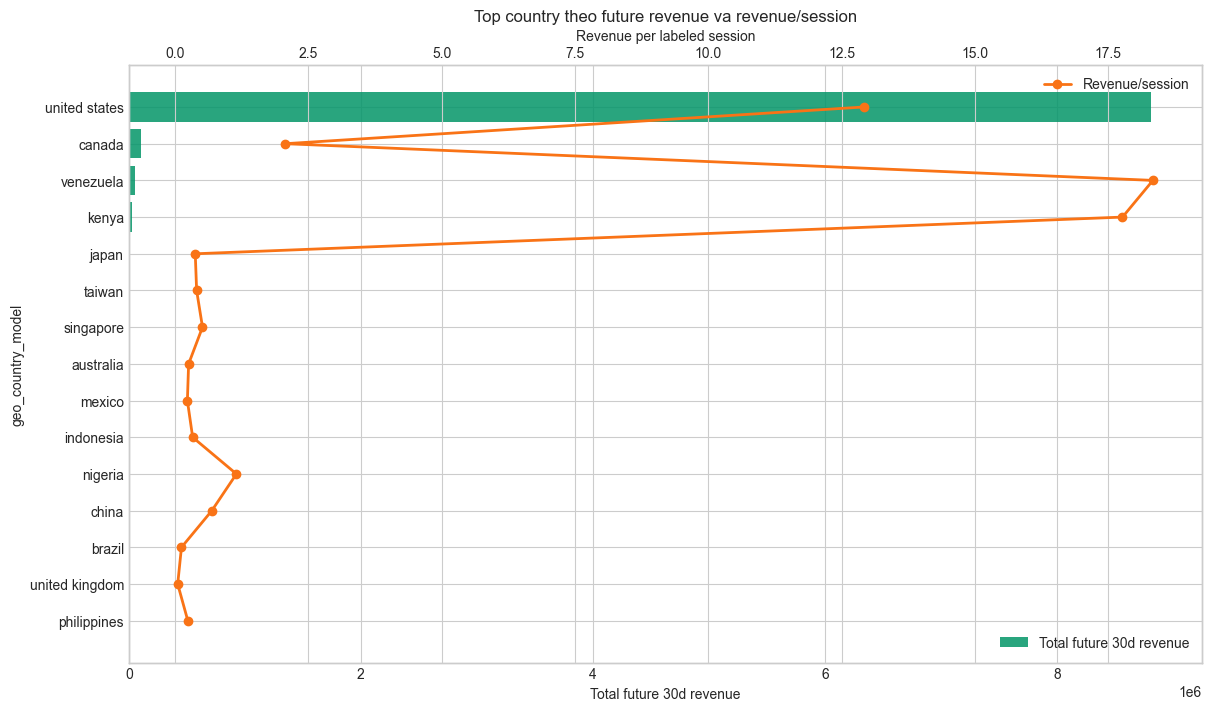

In [6]:
country_revenue_plot_pd = country_revenue_pd.sort_values("total_future_30d_revenue", ascending=True)

fig, ax1 = plt.subplots(figsize=(12, 7), constrained_layout=True)
ax1.barh(
    country_revenue_plot_pd["geo_country_model"],
    country_revenue_plot_pd["total_future_30d_revenue"],
    color="#059669",
    alpha=0.86,
    label="Total future 30d revenue",
)
ax1.set_title("Top country theo future revenue va revenue/session")
ax1.set_xlabel("Total future 30d revenue")
ax1.set_ylabel("geo_country_model")

ax2 = ax1.twiny()
ax2.plot(
    country_revenue_plot_pd["revenue_per_session"],
    country_revenue_plot_pd["geo_country_model"],
    color="#F97316",
    marker="o",
    linewidth=2,
    label="Revenue/session",
)
ax2.set_xlabel("Revenue per labeled session")

ax1.legend(loc="lower right")
ax2.legend(loc="upper right")
plt.show()

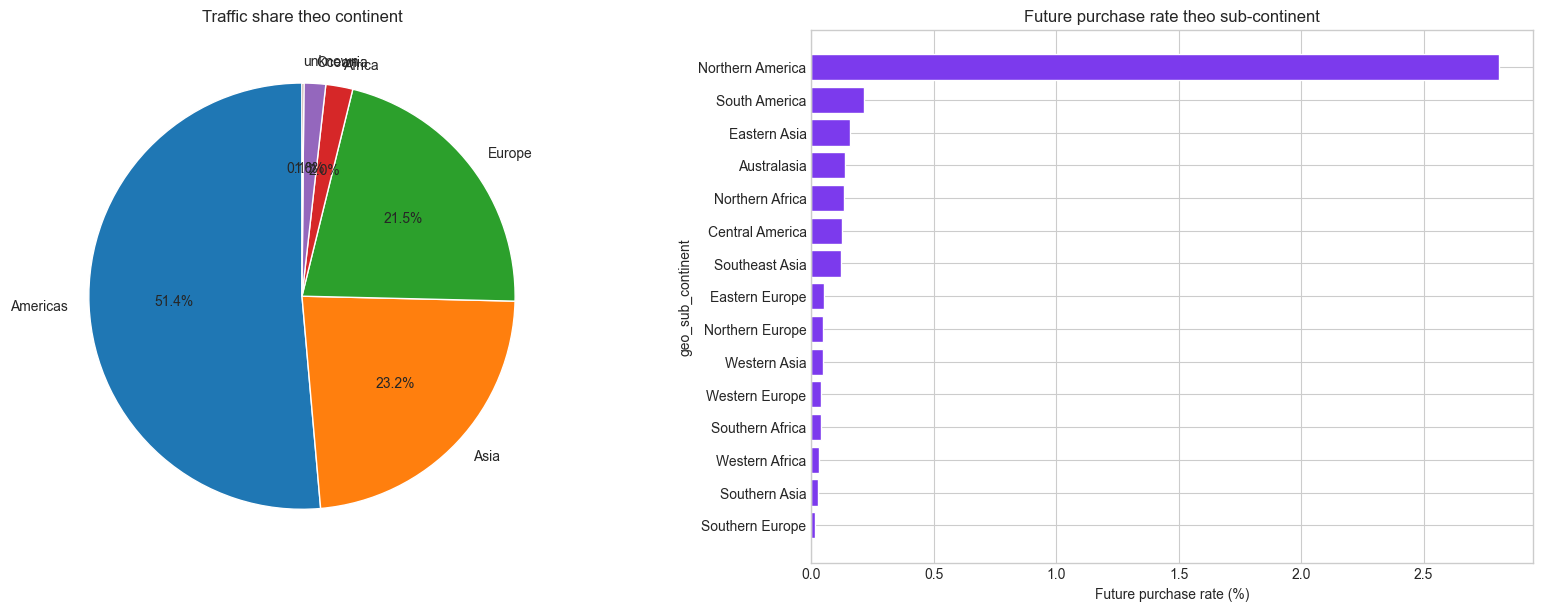

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

continent_plot_pd = continent_summary_pd.sort_values("labeled_session_count", ascending=False)
axes[0].pie(
    continent_plot_pd["labeled_session_count"],
    labels=continent_plot_pd["geo_continent"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
axes[0].set_title("Traffic share theo continent")

subcontinent_plot_pd = subcontinent_summary_pd.sort_values("future_purchase_rate_pct", ascending=True)
axes[1].barh(
    subcontinent_plot_pd["geo_sub_continent"],
    subcontinent_plot_pd["future_purchase_rate_pct"],
    color="#7C3AED",
    edgecolor="white",
)
axes[1].set_title("Future purchase rate theo sub-continent")
axes[1].set_xlabel("Future purchase rate (%)")
axes[1].set_ylabel("geo_sub_continent")

plt.show()

Voi geo, nen doc dong thoi volume va rate. Cac nuoc co revenue/session cao nhung volume qua nho can duoc gop nhom hoac dung encoding on dinh hon trong feature engineering.

## 4.7. Nhom engagement: muc do tuong tac trong session

In [2]:
spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", "8")
spark.conf.set("spark.sql.adaptive.enabled", "false")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

engagement_columns = [
    "fullVisitorId",
    "visit_id",
    "visit_number",
    "totals_hits",
    "totals_pageviews",
    "totals_bounces",
    "totals_new_visits",
    "totals_time_on_site",
    "totals_session_quality_dim",
    "is_bounce",
    "has_pageviews",
    "is_socially_engaged",
]

engagement_target_columns = [
    "fullVisitorId",
    "visit_id",
    "future_30d_has_purchase",
    "future_30d_revenue",
    "future_30d_purchase_count",
    "days_to_first_purchase",
    "has_full_30d_label_window",
]

engagement_analysis_columns = list(dict.fromkeys(engagement_target_columns + engagement_columns))

eda_engagement_analysis_df = read_clean_selected_columns(TRAIN_CLEAN_PATH, engagement_analysis_columns)
eda_engagement_df = eda_engagement_analysis_df.select(*engagement_columns)
eda_engagement_labeled_df = (
    eda_engagement_analysis_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select(*(engagement_target_columns + engagement_columns[2:]))
)

print("eda_engagement_df ready")
print("eda_engagement_labeled_df ready")
print("Engagement EDA is built without joins/deduplicate to keep Spark local stable.")

eda_engagement_df ready
eda_engagement_labeled_df ready
Engagement EDA is built without joins/deduplicate to keep Spark local stable.


In [3]:
eda_engagement_bucketed_df = (
    eda_engagement_labeled_df
    .withColumn("totals_hits_clean", F.coalesce(F.col("totals_hits").cast("double"), F.lit(0.0)))
    .withColumn("totals_pageviews_clean", F.coalesce(F.col("totals_pageviews").cast("double"), F.lit(0.0)))
    .withColumn("totals_time_on_site_clean", F.coalesce(F.col("totals_time_on_site").cast("double"), F.lit(0.0)))
    .withColumn("session_quality_clean", F.coalesce(F.col("totals_session_quality_dim").cast("double"), F.lit(0.0)))
    .withColumn(
        "hits_bucket",
        F.when(F.col("totals_hits_clean") <= 1, "01: 0-1")
        .when(F.col("totals_hits_clean") <= 3, "02: 2-3")
        .when(F.col("totals_hits_clean") <= 7, "03: 4-7")
        .when(F.col("totals_hits_clean") <= 15, "04: 8-15")
        .otherwise("05: 16+"),
    )
    .withColumn(
        "pageviews_bucket",
        F.when(F.col("totals_pageviews_clean") <= 1, "01: 0-1")
        .when(F.col("totals_pageviews_clean") <= 3, "02: 2-3")
        .when(F.col("totals_pageviews_clean") <= 7, "03: 4-7")
        .when(F.col("totals_pageviews_clean") <= 15, "04: 8-15")
        .otherwise("05: 16+"),
    )
    .withColumn(
        "time_on_site_bucket",
        F.when(F.col("totals_time_on_site_clean") <= 0, "01: 0s")
        .when(F.col("totals_time_on_site_clean") <= 30, "02: 1-30s")
        .when(F.col("totals_time_on_site_clean") <= 120, "03: 31-120s")
        .when(F.col("totals_time_on_site_clean") <= 600, "04: 2-10m")
        .otherwise("05: 10m+"),
    )
    .withColumn(
        "session_quality_bucket",
        F.when(F.col("session_quality_clean") <= 0, "01: 0")
        .when(F.col("session_quality_clean") <= 10, "02: 1-10")
        .when(F.col("session_quality_clean") <= 40, "03: 11-40")
        .when(F.col("session_quality_clean") <= 70, "04: 41-70")
        .otherwise("05: 71+"),
    )
    .withColumn(
        "visit_number_bucket",
        F.when(F.col("visit_number") <= 1, "01: first")
        .when(F.col("visit_number") <= 3, "02: 2-3")
        .when(F.col("visit_number") <= 10, "03: 4-10")
        .otherwise("04: 11+"),
    )
    .withColumn("bounce_label", F.when(F.col("is_bounce") == 1, "bounce").otherwise("non_bounce"))
    .withColumn("new_visit_label", F.when(F.col("totals_new_visits") == 1, "new_visit").otherwise("returning"))
)

def build_engagement_bucket_summary(bucket_column):
    summary_df = (
        eda_engagement_bucketed_df
        .groupBy(bucket_column)
        .agg(
            F.count("*").alias("labeled_session_count"),
            F.avg("future_30d_has_purchase").alias("future_purchase_rate"),
            F.avg("future_30d_revenue").alias("revenue_per_session"),
        )
        .withColumn("future_purchase_rate_pct", F.col("future_purchase_rate") * 100)
        .orderBy(bucket_column)
    )
    return pd.DataFrame([row.asDict() for row in summary_df.collect()])

hits_bucket_pd = build_engagement_bucket_summary("hits_bucket")
pageviews_bucket_pd = build_engagement_bucket_summary("pageviews_bucket")
time_on_site_bucket_pd = build_engagement_bucket_summary("time_on_site_bucket")
session_quality_bucket_pd = build_engagement_bucket_summary("session_quality_bucket")
visit_number_bucket_pd = build_engagement_bucket_summary("visit_number_bucket")
bounce_bucket_pd = build_engagement_bucket_summary("bounce_label")
new_visit_bucket_pd = build_engagement_bucket_summary("new_visit_label")

display(pageviews_bucket_pd)
display(time_on_site_bucket_pd)

,pageviews_bucket,labeled_session_count,future_purchase_rate,revenue_per_session,future_purchase_rate_pct
0,01: 0-1,834623,0.004337,1.394788,0.433729
1,02: 2-3,373694,0.009687,4.954914,0.968707
2,03: 4-7,223813,0.019467,8.811129,1.946714
3,04: 8-15,125558,0.036605,11.025703,3.660460
4,05: 16+,66390,0.076457,40.816769,7.645730


,time_on_site_bucket,labeled_session_count,future_purchase_rate,revenue_per_session,future_purchase_rate_pct
0,01: 0s,832562,0.004293,1.386657,0.429277
1,02: 1-30s,195007,0.013220,7.999970,1.322004
2,03: 31-120s,280228,0.012618,4.634777,1.261830
3,04: 2-10m,224501,0.028815,9.453327,2.881502
4,05: 10m+,91780,0.055698,32.102590,5.569841


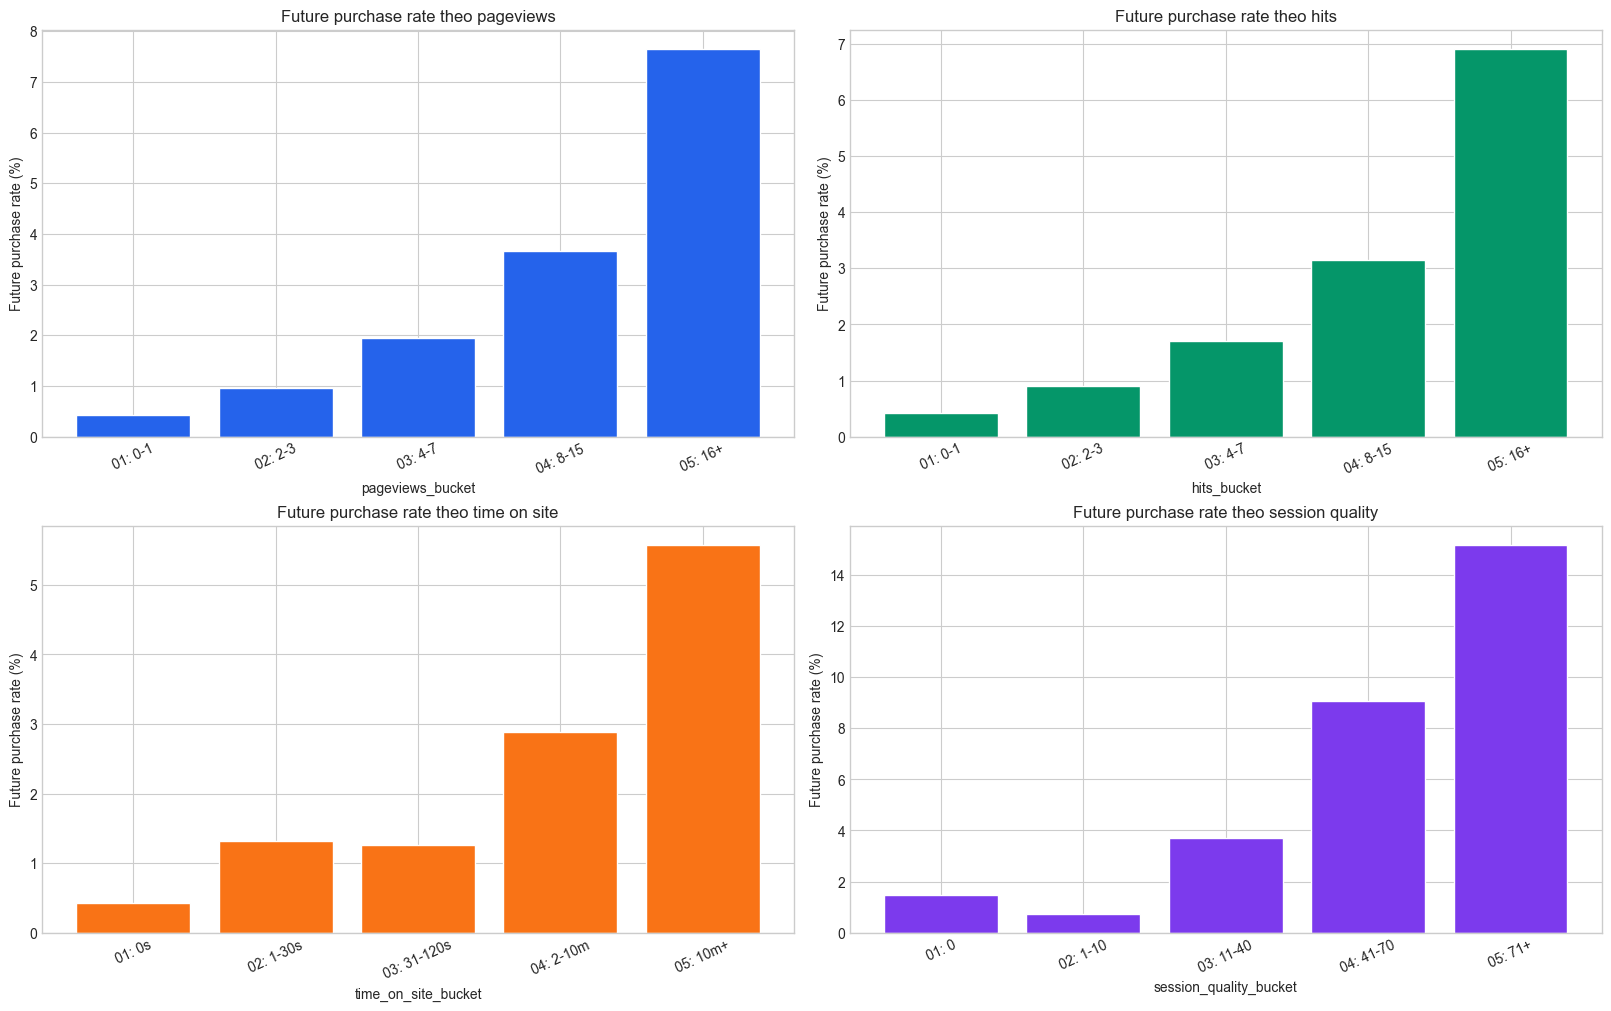

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

bucket_plots = [
    (pageviews_bucket_pd, "pageviews_bucket", "Future purchase rate theo pageviews", "#2563EB"),
    (hits_bucket_pd, "hits_bucket", "Future purchase rate theo hits", "#059669"),
    (time_on_site_bucket_pd, "time_on_site_bucket", "Future purchase rate theo time on site", "#F97316"),
    (session_quality_bucket_pd, "session_quality_bucket", "Future purchase rate theo session quality", "#7C3AED"),
]

for ax, (plot_pd, bucket_col, title, color) in zip(axes.ravel(), bucket_plots):
    ax.bar(plot_pd[bucket_col], plot_pd["future_purchase_rate_pct"], color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(bucket_col)
    ax.set_ylabel("Future purchase rate (%)")
    ax.tick_params(axis="x", rotation=25)

plt.show()

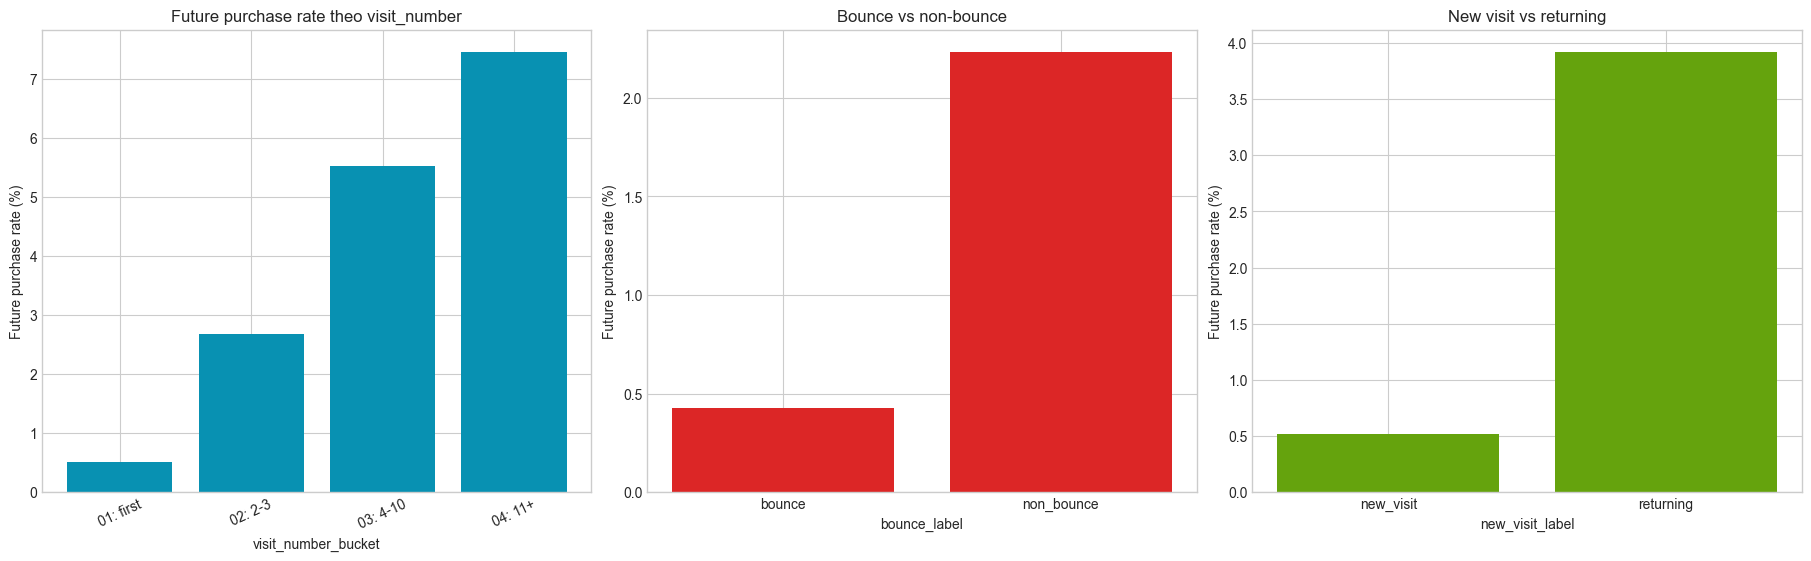

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

axes[0].bar(visit_number_bucket_pd["visit_number_bucket"], visit_number_bucket_pd["future_purchase_rate_pct"], color="#0891B2")
axes[0].set_title("Future purchase rate theo visit_number")
axes[0].set_xlabel("visit_number_bucket")
axes[0].set_ylabel("Future purchase rate (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(bounce_bucket_pd["bounce_label"], bounce_bucket_pd["future_purchase_rate_pct"], color="#DC2626")
axes[1].set_title("Bounce vs non-bounce")
axes[1].set_xlabel("bounce_label")
axes[1].set_ylabel("Future purchase rate (%)")

axes[2].bar(new_visit_bucket_pd["new_visit_label"], new_visit_bucket_pd["future_purchase_rate_pct"], color="#65A30D")
axes[2].set_title("New visit vs returning")
axes[2].set_xlabel("new_visit_label")
axes[2].set_ylabel("Future purchase rate (%)")

plt.show()

Neu purchase rate tang theo pageviews, hits, time on site hoac session quality, nhom engagement la ung vien feature manh. Bounce va new/returning nen doc cung volume vi cac nhom nay thuong rat lech.

## 4.8. Nhom sparse flags: campaign, gclid, referral va missing signal

In [6]:
spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", "8")
spark.conf.set("spark.sql.adaptive.enabled", "false")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

sparse_flag_columns = [
    "fullVisitorId",
    "visit_id",
    "has_traffic_keyword",
    "has_gclid",
    "has_traffic_campaign",
    "has_traffic_ad_content",
    "has_referral_path",
    "has_geo_metro",
    "has_custom_dimension",
    "has_geo_region",
]

sparse_target_columns = [
    "fullVisitorId",
    "visit_id",
    "future_30d_has_purchase",
    "future_30d_revenue",
    "has_full_30d_label_window",
]

sparse_analysis_columns = list(dict.fromkeys(sparse_target_columns + sparse_flag_columns))

eda_sparse_flags_analysis_df = read_clean_selected_columns(TRAIN_CLEAN_PATH, sparse_analysis_columns)
eda_sparse_flags_df = eda_sparse_flags_analysis_df.select(*sparse_flag_columns)
eda_sparse_flags_labeled_df = (
    eda_sparse_flags_analysis_df
    .where(F.col("has_full_30d_label_window") == 1)
    .select(*(sparse_target_columns + sparse_flag_columns[2:]))
)

print("eda_sparse_flags_df ready")
print("eda_sparse_flags_labeled_df ready")
print("Sparse flags EDA is built without joins/deduplicate to keep Spark local stable.")

eda_sparse_flags_df ready
eda_sparse_flags_labeled_df ready
Sparse flags EDA is built without joins/deduplicate to keep Spark local stable.


In [7]:
flag_summary_frames = []

for flag_col in sparse_flag_columns[2:]:
    one_flag_df = (
        eda_sparse_flags_labeled_df
        .withColumn("flag_value", F.coalesce(F.col(flag_col).cast("int"), F.lit(0)))
        .groupBy("flag_value")
        .agg(
            F.count("*").alias("labeled_session_count"),
            F.avg("future_30d_has_purchase").alias("future_purchase_rate"),
            F.avg("future_30d_revenue").alias("revenue_per_session"),
            F.sum("future_30d_revenue").alias("total_future_30d_revenue"),
        )
        .withColumn("future_purchase_rate_pct", F.col("future_purchase_rate") * 100)
        .withColumn("flag", F.lit(flag_col))
    )
    one_flag_pd = pd.DataFrame([row.asDict() for row in one_flag_df.collect()])
    flag_summary_frames.append(one_flag_pd)

sparse_flags_summary_pd = pd.concat(flag_summary_frames, ignore_index=True)
sparse_flags_positive_pd = sparse_flags_summary_pd[sparse_flags_summary_pd["flag_value"] == 1].copy()
sparse_flags_positive_pd = sparse_flags_positive_pd.sort_values("future_purchase_rate_pct", ascending=False)

display(sparse_flags_summary_pd.sort_values(["flag", "flag_value"]))
display(sparse_flags_positive_pd)

,flag_value,labeled_session_count,future_purchase_rate,revenue_per_session,total_future_30d_revenue,future_purchase_rate_pct,flag
13,0,318252,0.001053,0.334472,106446.54,0.105262,has_custom_dimension
12,1,1305826,0.016031,6.873453,8975533.08,1.603123,has_custom_dimension
3,0,1549040,0.013298,5.791067,8970594.86,1.329791,has_gclid
2,1,75038,0.008929,1.484378,111384.76,0.892881,has_gclid
11,0,1256900,0.006366,4.985724,6266556.64,0.636646,has_geo_metro
10,1,367178,0.036132,7.667733,2815422.98,3.613234,has_geo_metro
15,0,938104,0.008074,6.554898,6149175.90,0.807373,has_geo_region
14,1,685974,0.019964,4.275386,2932803.72,1.996431,has_geo_region
9,0,1084938,0.010245,6.661094,7226874.12,1.024483,has_referral_path
8,1,539140,0.018834,3.440860,1855105.50,1.883370,has_referral_path


,flag_value,labeled_session_count,future_purchase_rate,revenue_per_session,total_future_30d_revenue,future_purchase_rate_pct,flag
10,1,367178,0.036132,7.667733,2815422.98,3.613234,has_geo_metro
14,1,685974,0.019964,4.275386,2932803.72,1.996431,has_geo_region
8,1,539140,0.018834,3.440860,1855105.50,1.883370,has_referral_path
12,1,1305826,0.016031,6.873453,8975533.08,1.603123,has_custom_dimension
2,1,75038,0.008929,1.484378,111384.76,0.892881,has_gclid
0,1,84294,0.007165,1.166490,98328.12,0.716540,has_traffic_keyword
4,1,99657,0.005278,0.911479,90835.27,0.527810,has_traffic_campaign
6,1,62505,0.004624,0.855498,53472.90,0.462363,has_traffic_ad_content


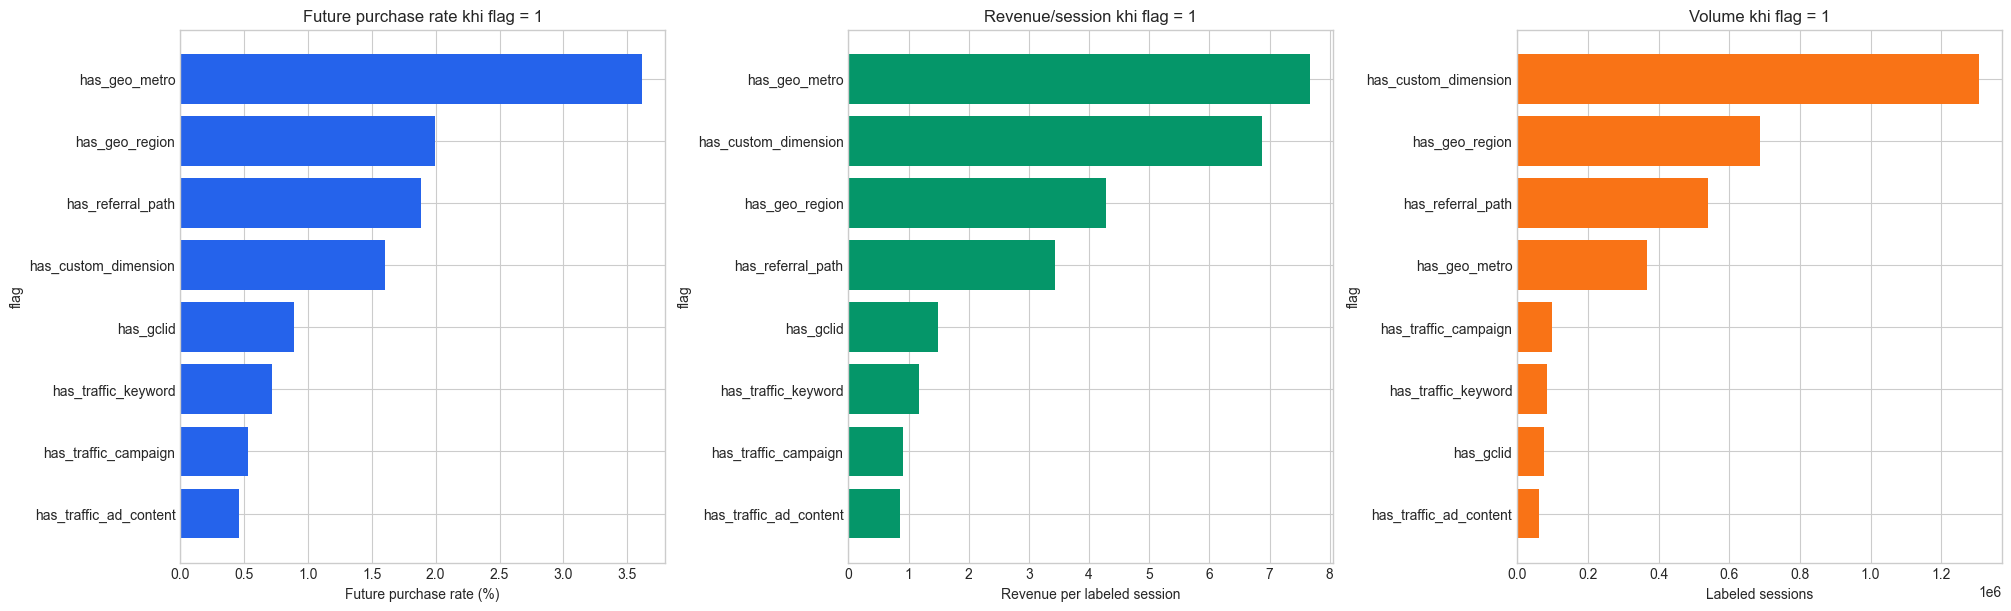

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

plot_flags_pd = sparse_flags_positive_pd.sort_values("future_purchase_rate_pct", ascending=True)

axes[0].barh(plot_flags_pd["flag"], plot_flags_pd["future_purchase_rate_pct"], color="#2563EB")
axes[0].set_title("Future purchase rate khi flag = 1")
axes[0].set_xlabel("Future purchase rate (%)")
axes[0].set_ylabel("flag")

plot_revenue_pd = sparse_flags_positive_pd.sort_values("revenue_per_session", ascending=True)
axes[1].barh(plot_revenue_pd["flag"], plot_revenue_pd["revenue_per_session"], color="#059669")
axes[1].set_title("Revenue/session khi flag = 1")
axes[1].set_xlabel("Revenue per labeled session")
axes[1].set_ylabel("flag")

plot_volume_pd = sparse_flags_positive_pd.sort_values("labeled_session_count", ascending=True)
axes[2].barh(plot_volume_pd["flag"], plot_volume_pd["labeled_session_count"], color="#F97316")
axes[2].set_title("Volume khi flag = 1")
axes[2].set_xlabel("Labeled sessions")
axes[2].set_ylabel("flag")

plt.show()

Flag dang 0/1 giup bien cac truong raw rat sparse thanh tin hieu on dinh hon. Khi flag co rate/revenue cao nhung volume thap, nen uu tien flag hon raw category de giam overfit.

## 4.9. Nhom user history: tan suat, gan day, monetary va engagement lich su

In [9]:
spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", "8")
spark.conf.set("spark.sql.adaptive.enabled", "false")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

from pyspark.sql import Window

user_history_target_columns = [
    "fullVisitorId",
    "visit_id",
    "future_30d_has_purchase",
    "future_30d_revenue",
    "has_full_30d_label_window",
]

user_history_columns = [
    "fullVisitorId",
    "visit_id",
    "visit_start_time",
    "session_date",
    "visit_number",
    "totals_hits",
    "totals_pageviews",
    "totals_time_on_site",
    "totals_bounces",
    "totals_new_visits",
    "session_has_purchase_signal",
    "session_revenue_signal",
    "channelGrouping_model",
    "device_category_model",
    "geo_country_model",
]

user_history_analysis_columns = list(dict.fromkeys(user_history_target_columns + user_history_columns))

user_history_source_df = (
    read_clean_selected_columns(TRAIN_CLEAN_PATH, user_history_analysis_columns)
    .withColumn("session_date", F.to_date("session_date"))
    .withColumn("visit_start_time", F.col("visit_start_time").cast("long"))
    .withColumn("hits_clean", F.coalesce(F.col("totals_hits").cast("double"), F.lit(0.0)))
    .withColumn("pageviews_clean", F.coalesce(F.col("totals_pageviews").cast("double"), F.lit(0.0)))
    .withColumn("time_on_site_clean", F.coalesce(F.col("totals_time_on_site").cast("double"), F.lit(0.0)))
    .withColumn("bounce_clean", F.coalesce(F.col("totals_bounces").cast("double"), F.lit(0.0)))
    .withColumn("new_visit_clean", F.coalesce(F.col("totals_new_visits").cast("double"), F.lit(0.0)))
    .withColumn("session_has_purchase_signal_clean", F.coalesce(F.col("session_has_purchase_signal").cast("int"), F.lit(0)))
    .withColumn("session_revenue_signal_clean", F.coalesce(F.col("session_revenue_signal").cast("double"), F.lit(0.0)))
)

user_order_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time", "visit_id").rowsBetween(Window.unboundedPreceding, Window.currentRow)
user_previous_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time", "visit_id").rowsBetween(Window.unboundedPreceding, -1)
user_lag_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time", "visit_id")
user_range_7d_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time").rangeBetween(-7 * 86400, 0)
user_range_30d_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time").rangeBetween(-30 * 86400, 0)
user_range_90d_window = Window.partitionBy("fullVisitorId").orderBy("visit_start_time").rangeBetween(-90 * 86400, 0)

eda_user_history_with_target_df = (
    user_history_source_df
    .withColumn("user_total_sessions_to_date", F.coalesce(F.col("visit_number").cast("long"), F.row_number().over(user_lag_window)))
    .withColumn("user_total_hits_to_date", F.sum("hits_clean").over(user_order_window))
    .withColumn("user_total_pageviews_to_date", F.sum("pageviews_clean").over(user_order_window))
    .withColumn("user_total_time_on_site_to_date", F.sum("time_on_site_clean").over(user_order_window))
    .withColumn("user_avg_hits_to_date", F.col("user_total_hits_to_date") / F.col("user_total_sessions_to_date"))
    .withColumn("user_avg_pageviews_to_date", F.col("user_total_pageviews_to_date") / F.col("user_total_sessions_to_date"))
    .withColumn("user_avg_time_on_site_to_date", F.col("user_total_time_on_site_to_date") / F.col("user_total_sessions_to_date"))
    .withColumn("user_bounce_rate_to_date", F.sum("bounce_clean").over(user_order_window) / F.col("user_total_sessions_to_date"))
    .withColumn("user_new_visit_rate_to_date", F.sum("new_visit_clean").over(user_order_window) / F.col("user_total_sessions_to_date"))
    .withColumn("user_previous_purchase_count", F.coalesce(F.sum("session_has_purchase_signal_clean").over(user_previous_window), F.lit(0)))
    .withColumn("user_previous_revenue", F.coalesce(F.sum("session_revenue_signal_clean").over(user_previous_window), F.lit(0.0)))
    .withColumn(
        "previous_purchase_visit_start_time",
        F.max(F.when(F.col("session_has_purchase_signal_clean") == 1, F.col("visit_start_time"))).over(user_previous_window),
    )
    .withColumn(
        "user_days_since_previous_purchase",
        F.when(
            F.col("previous_purchase_visit_start_time").isNotNull(),
            (F.col("visit_start_time") - F.col("previous_purchase_visit_start_time")) / 86400.0,
        ),
    )
    .withColumn("user_first_session_date", F.min("session_date").over(user_order_window))
    .withColumn("user_days_since_first_session", F.datediff(F.col("session_date"), F.col("user_first_session_date")))
    .withColumn("previous_session_visit_start_time", F.lag("visit_start_time").over(user_lag_window))
    .withColumn(
        "user_days_since_previous_session",
        F.when(
            F.col("previous_session_visit_start_time").isNotNull(),
            (F.col("visit_start_time") - F.col("previous_session_visit_start_time")) / 86400.0,
        ),
    )
    .withColumn("user_active_days_to_date", F.col("user_total_sessions_to_date"))
    .withColumn("user_sessions_last_7d", F.count(F.lit(1)).over(user_range_7d_window))
    .withColumn("user_sessions_last_30d", F.count(F.lit(1)).over(user_range_30d_window))
    .withColumn("user_sessions_last_90d", F.count(F.lit(1)).over(user_range_90d_window))
    .withColumn("user_main_channel_to_date", F.coalesce(F.col("channelGrouping_model"), F.lit("(missing)")))
    .withColumn("user_main_device_to_date", F.coalesce(F.col("device_category_model"), F.lit("(missing)")))
    .withColumn("user_main_country_to_date", F.coalesce(F.col("geo_country_model"), F.lit("(missing)")))
    .select(
        "fullVisitorId",
        "visit_id",
        "future_30d_has_purchase",
        "future_30d_revenue",
        "has_full_30d_label_window",
        "user_total_sessions_to_date",
        "user_total_hits_to_date",
        "user_total_pageviews_to_date",
        "user_total_time_on_site_to_date",
        "user_avg_hits_to_date",
        "user_avg_pageviews_to_date",
        "user_avg_time_on_site_to_date",
        "user_bounce_rate_to_date",
        "user_new_visit_rate_to_date",
        "user_previous_purchase_count",
        "user_previous_revenue",
        "user_days_since_previous_purchase",
        "user_main_channel_to_date",
        "user_main_device_to_date",
        "user_main_country_to_date",
        "user_active_days_to_date",
        "user_days_since_first_session",
        "user_days_since_previous_session",
        "user_sessions_last_7d",
        "user_sessions_last_30d",
        "user_sessions_last_90d",
    )
)

eda_user_history_df = eda_user_history_with_target_df.drop(
    "future_30d_has_purchase",
    "future_30d_revenue",
    "has_full_30d_label_window",
)

eda_user_history_labeled_df = eda_user_history_with_target_df.where(F.col("has_full_30d_label_window") == 1)

print("eda_user_history_df ready")
print("eda_user_history_labeled_df ready")
print("User history EDA avoids collect_set/collect_list UDFs, persist, and immediate counts.")

eda_user_history_df ready
eda_user_history_labeled_df ready
User history EDA avoids collect_set/collect_list UDFs, persist, and immediate counts.


In [10]:
available_eda_groups = []

for group_name in [
    "eda_base_keys_df",
    "eda_target_df",
    "eda_time_df",
    "eda_traffic_df",
    "eda_device_df",
    "eda_geo_df",
    "eda_engagement_df",
    "eda_sparse_flags_df",
    "eda_user_history_df",
]:
    if group_name in globals():
        available_eda_groups.append({
            "group": group_name,
            "column_count": len(globals()[group_name].columns),
            "columns": ", ".join(globals()[group_name].columns),
        })

eda_group_schema_pd = pd.DataFrame(available_eda_groups)
display(eda_group_schema_pd)

print("Skipped materializing final eda_train_df join here to keep Spark local stable.")
print("Use the group-level dataframes above for EDA charts; build a final feature table later in the feature engineering notebook.")

,group,column_count,columns
0,eda_engagement_df,12,"fullVisitorId, visit_id, visit_number, totals_..."
1,eda_sparse_flags_df,10,"fullVisitorId, visit_id, has_traffic_keyword, ..."
2,eda_user_history_df,23,"fullVisitorId, visit_id, user_total_sessions_t..."


Skipped materializing final eda_train_df join here to keep Spark local stable.
Use the group-level dataframes above for EDA charts; build a final feature table later in the feature engineering notebook.


In [11]:
previous_revenue_quantiles = (
    eda_user_history_labeled_df
    .where(F.col("user_previous_revenue") > 0)
    .agg(
        F.percentile_approx("user_previous_revenue", 0.33).alias("p33"),
        F.percentile_approx("user_previous_revenue", 0.66).alias("p66"),
    )
    .first()
)

previous_revenue_p33 = previous_revenue_quantiles["p33"] if previous_revenue_quantiles and previous_revenue_quantiles["p33"] is not None else 0
previous_revenue_p66 = previous_revenue_quantiles["p66"] if previous_revenue_quantiles and previous_revenue_quantiles["p66"] is not None else 0

eda_user_history_bucketed_df = (
    eda_user_history_labeled_df
    .withColumn(
        "sessions_to_date_bucket",
        F.when(F.col("user_total_sessions_to_date") <= 1, "01: 1")
        .when(F.col("user_total_sessions_to_date") <= 2, "02: 2")
        .when(F.col("user_total_sessions_to_date") <= 5, "03: 3-5")
        .when(F.col("user_total_sessions_to_date") <= 10, "04: 6-10")
        .otherwise("05: 11+"),
    )
    .withColumn(
        "recency_bucket",
        F.when(F.col("user_days_since_previous_session").isNull(), "01: first_session")
        .when(F.col("user_days_since_previous_session") <= 1, "02: <=1d")
        .when(F.col("user_days_since_previous_session") <= 7, "03: 2-7d")
        .when(F.col("user_days_since_previous_session") <= 30, "04: 8-30d")
        .when(F.col("user_days_since_previous_session") <= 90, "05: 31-90d")
        .otherwise("06: 90d+"),
    )
    .withColumn(
        "previous_purchase_count_bucket",
        F.when(F.col("user_previous_purchase_count") <= 0, "01: 0")
        .when(F.col("user_previous_purchase_count") == 1, "02: 1")
        .when(F.col("user_previous_purchase_count") == 2, "03: 2")
        .otherwise("04: 3+"),
    )
    .withColumn(
        "previous_revenue_bucket",
        F.when(F.col("user_previous_revenue") <= 0, "01: 0")
        .when(F.col("user_previous_revenue") <= previous_revenue_p33, "02: low")
        .when(F.col("user_previous_revenue") <= previous_revenue_p66, "03: mid")
        .otherwise("04: high"),
    )
    .withColumn(
        "avg_pageviews_to_date_bucket",
        F.when(F.col("user_avg_pageviews_to_date") <= 1, "01: 0-1")
        .when(F.col("user_avg_pageviews_to_date") <= 3, "02: 2-3")
        .when(F.col("user_avg_pageviews_to_date") <= 7, "03: 4-7")
        .when(F.col("user_avg_pageviews_to_date") <= 15, "04: 8-15")
        .otherwise("05: 16+"),
    )
    .withColumn(
        "bounce_rate_to_date_bucket",
        F.when(F.col("user_bounce_rate_to_date") <= 0, "01: 0")
        .when(F.col("user_bounce_rate_to_date") <= 0.25, "02: <=25%")
        .when(F.col("user_bounce_rate_to_date") <= 0.5, "03: 26-50%")
        .when(F.col("user_bounce_rate_to_date") <= 0.75, "04: 51-75%")
        .otherwise("05: 76-100%"),
    )
)

def build_user_history_bucket_summary(bucket_column):
    summary_df = (
        eda_user_history_bucketed_df
        .groupBy(bucket_column)
        .agg(
            F.count("*").alias("labeled_session_count"),
            F.avg("future_30d_has_purchase").alias("future_purchase_rate"),
            F.avg("future_30d_revenue").alias("revenue_per_session"),
        )
        .withColumn("future_purchase_rate_pct", F.col("future_purchase_rate") * 100)
        .orderBy(bucket_column)
    )
    return pd.DataFrame([row.asDict() for row in summary_df.collect()])

sessions_to_date_bucket_pd = build_user_history_bucket_summary("sessions_to_date_bucket")
recency_bucket_pd = build_user_history_bucket_summary("recency_bucket")
previous_purchase_count_bucket_pd = build_user_history_bucket_summary("previous_purchase_count_bucket")
previous_revenue_bucket_pd = build_user_history_bucket_summary("previous_revenue_bucket")
avg_pageviews_to_date_bucket_pd = build_user_history_bucket_summary("avg_pageviews_to_date_bucket")
bounce_rate_to_date_bucket_pd = build_user_history_bucket_summary("bounce_rate_to_date_bucket")

display(sessions_to_date_bucket_pd)
display(recency_bucket_pd)

,sessions_to_date_bucket,labeled_session_count,future_purchase_rate,revenue_per_session,future_purchase_rate_pct
0,01: 1,1245819,0.005166,0.822267,0.516608
1,02: 2,172435,0.022594,4.397539,2.259402
2,03: 3-5,124643,0.043653,10.138059,4.365267
3,04: 6-10,43823,0.061817,18.659739,6.181685
4,05: 11+,37358,0.074602,139.673709,7.460249


,recency_bucket,labeled_session_count,future_purchase_rate,revenue_per_session,future_purchase_rate_pct
0,01: first_session,1262339,0.005548,0.893191,0.554843
1,02: <=1d,173427,0.038956,27.166242,3.895587
2,03: 2-7d,89203,0.045772,25.171052,4.577200
3,04: 8-30d,67722,0.039278,12.598761,3.927823
4,05: 31-90d,22428,0.027109,5.481091,2.710897
5,06: 90d+,8959,0.017636,2.414735,1.763590


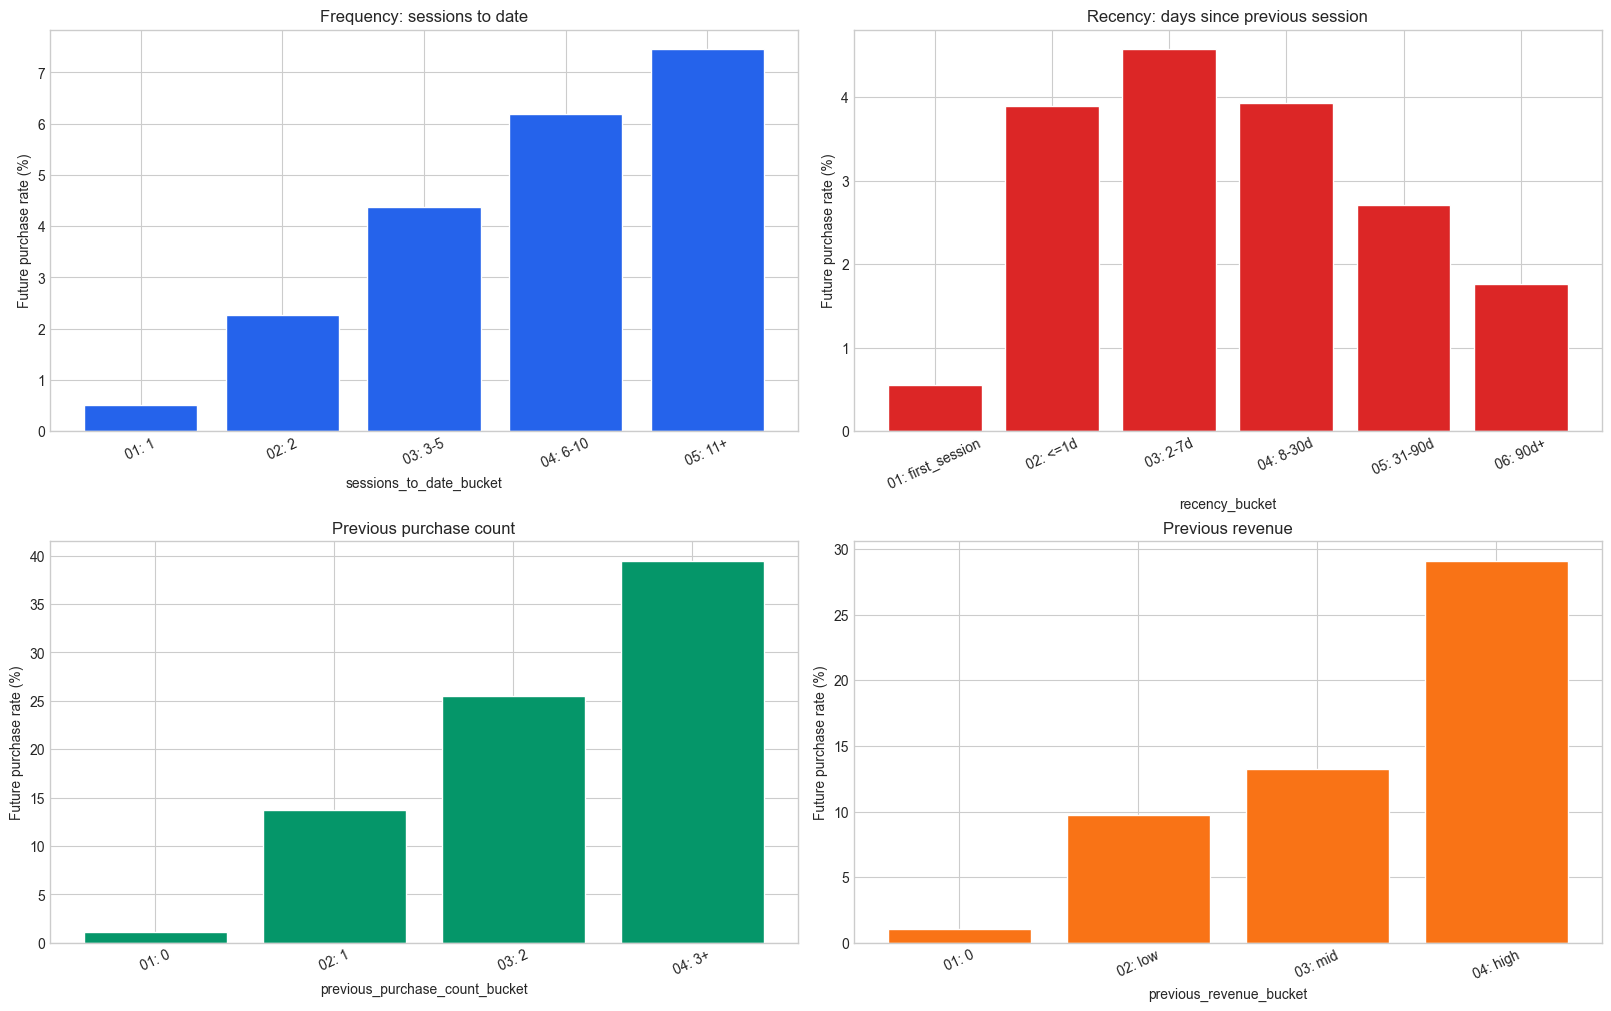

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

history_bucket_plots = [
    (sessions_to_date_bucket_pd, "sessions_to_date_bucket", "Frequency: sessions to date", "#2563EB"),
    (recency_bucket_pd, "recency_bucket", "Recency: days since previous session", "#DC2626"),
    (previous_purchase_count_bucket_pd, "previous_purchase_count_bucket", "Previous purchase count", "#059669"),
    (previous_revenue_bucket_pd, "previous_revenue_bucket", "Previous revenue", "#F97316"),
]

for ax, (plot_pd, bucket_col, title, color) in zip(axes.ravel(), history_bucket_plots):
    ax.bar(plot_pd[bucket_col], plot_pd["future_purchase_rate_pct"], color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(bucket_col)
    ax.set_ylabel("Future purchase rate (%)")
    ax.tick_params(axis="x", rotation=25)

plt.show()

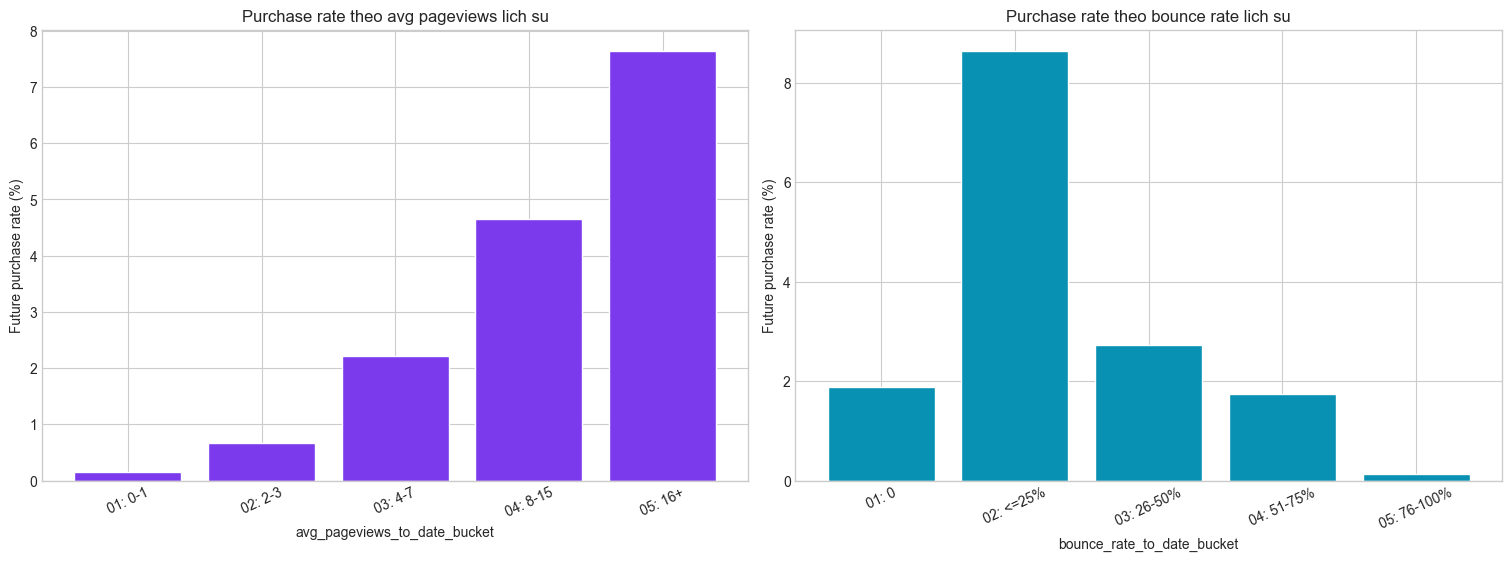

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

axes[0].bar(
    avg_pageviews_to_date_bucket_pd["avg_pageviews_to_date_bucket"],
    avg_pageviews_to_date_bucket_pd["future_purchase_rate_pct"],
    color="#7C3AED",
    edgecolor="white",
)
axes[0].set_title("Purchase rate theo avg pageviews lich su")
axes[0].set_xlabel("avg_pageviews_to_date_bucket")
axes[0].set_ylabel("Future purchase rate (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(
    bounce_rate_to_date_bucket_pd["bounce_rate_to_date_bucket"],
    bounce_rate_to_date_bucket_pd["future_purchase_rate_pct"],
    color="#0891B2",
    edgecolor="white",
)
axes[1].set_title("Purchase rate theo bounce rate lich su")
axes[1].set_xlabel("bounce_rate_to_date_bucket")
axes[1].set_ylabel("Future purchase rate (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.show()

Nhom user history nen duoc uu tien cao trong feature engineering vi no gom recency, frequency, monetary va engagement tich luy. Cac bien previous purchase/revenue o tren chi lay session truoc do, tranh dung thong tin mua hang cua chinh session hien tai.